# dual_adc_usb — two-channel 12-bit, 10 MSa/s USB digitizer

This notebook walks through the design phase by phase: requirements, architecture, component
calculations, sourcing, the SKiDL code for each block, and the top-level assembly with ERC.

**Sources.** Numbers and decisions come from the pipeline documents in this directory:
`SPEC.md`, `architecture/*.md`, `sourcing/sourced_bom.csv`, `datasheets/*_SUMMARY.md` and
`handoffs/*.md`. The block code cells are copies of `circuits/dual_adc_usb/*.py` made when the
notebook was generated. **The `.py` files are the source of truth**; if they change, regenerate
the notebook with `python build_notebook.py` rather than editing the cells here.

**Running.** Start Jupyter from the project root (the directory holding `SPEC.md`). The last
section runs ERC over the whole circuit; it needs SKiDL, the KiCad 9 symbol libraries, and the
project-local symbol library in `symbols/`.

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import graphviz
from scipy.optimize import brentq

from skidl import *

PROJ = Path.cwd()
assert (PROJ / 'SPEC.md').exists(), 'start the notebook from the project root'

# Project-local symbol library (dual_adc_usb.kicad_sym) and footprint library (BNC).
if str(PROJ / 'symbols') not in lib_search_paths[KICAD9]:
    lib_search_paths[KICAD9].append(str(PROJ / 'symbols'))
if str(PROJ / 'footprints') not in footprint_search_paths[KICAD9]:
    footprint_search_paths[KICAD9].append(str(PROJ / 'footprints'))

# Engineering-notation helper for printed results.
def eng(x, unit='', digits=4):
    if x == 0:
        return f'0 {unit}'
    exp = int(np.floor(np.log10(abs(x)) / 3) * 3)
    exp = max(min(exp, 12), -15)
    prefix = {-15: 'f', -12: 'p', -9: 'n', -6: 'µ', -3: 'm', 0: '', 3: 'k', 6: 'M', 9: 'G', 12: 'T'}[exp]
    return f'{x / 10**exp:.{digits}g} {prefix}{unit}'

## 1. Requirements

Condensed from `SPEC.md`. [HARD] items came from the user; [SOFT] items were chosen by the
pipeline driver and are open to revision.

| Item | Requirement | Kind |
|---|---|---|
| Channels | 2, simultaneously sampled | HARD |
| Input range | ±10 V at the connector | HARD |
| Sample rate / resolution | 10 MSa/s per channel, 12 bit | HARD |
| Capture depth | ≥ 0.1 s at full rate → ≥ 1 M samples/channel | HARD |
| Connectors | 2 × BNC (scope-probe compatible); USB for power and data | HARD |
| Power | USB bus-powered; use USB-C (1.5 A) if the estimated draw exceeds ~2.0 W | HARD |
| Input impedance | ≈ 1 MΩ ‖ 20 pF (so 1×/10× probes compensate) | SOFT |
| Bandwidth | ≥ 5 MHz with anti-alias filtering | SOFT |
| Overvoltage | survive ±30 V continuous | SOFT |
| Transfer | capture-to-memory, then upload (streaming not required) | SOFT |

## 2. Architecture

Key decisions (`architecture/ic_selection.md`, `handoffs/02_architecture.md`):

- **ADC: TI ADS5231**, dual 12-bit, 40 MSa/s, one die → the two channels are sampled on the same
  clock edge. Its PLL mode needs ≥ 20 MSa/s, so the ADC **oversamples at 40 MSa/s** and the FPGA
  **decimates ×4** to 10 MSa/s. Oversampling also moves the first alias band from 5 MHz out to
  35 MHz, which is what makes an analog anti-alias filter practical at all (§3.4).
  (The claim that the ADS5231 cannot run below 20 MSa/s was contradicted in a later run — it can
  with the PLL off — but oversampling remains the better choice for the filter.)
- **Front end** per channel: compensated 909 k / 100 k divider (≈ 1 MΩ ‖ 20 pF, ÷10.09), BAV199
  clamp to the buffer rails, OPA356 unity buffer, THS4551 fully-differential amplifier wired as a
  2-pole multiple-feedback (MFB) low-pass, and a 49.9 Ω / 56 pF output RC at the ADC pins.
- **Capture engine: Gowin GW1NR-9** FPGA with 64 Mbit (8 MB) PSRAM inside the package — no
  external memory to route.
- **USB: FTDI FT232H** in synchronous-245 FIFO mode (≈ 35 MB/s, no firmware).
- **Power:** worst-case estimate 2.03 W > 2.0 W threshold, so a USB-C receptacle with 5.1 kΩ Rd
  pull-downs. Worst-case current (≈ 450 mA as built, §3.7) still fits a legacy 500 mA port.

### 2.1 Signal flow: analog inputs → USB connector

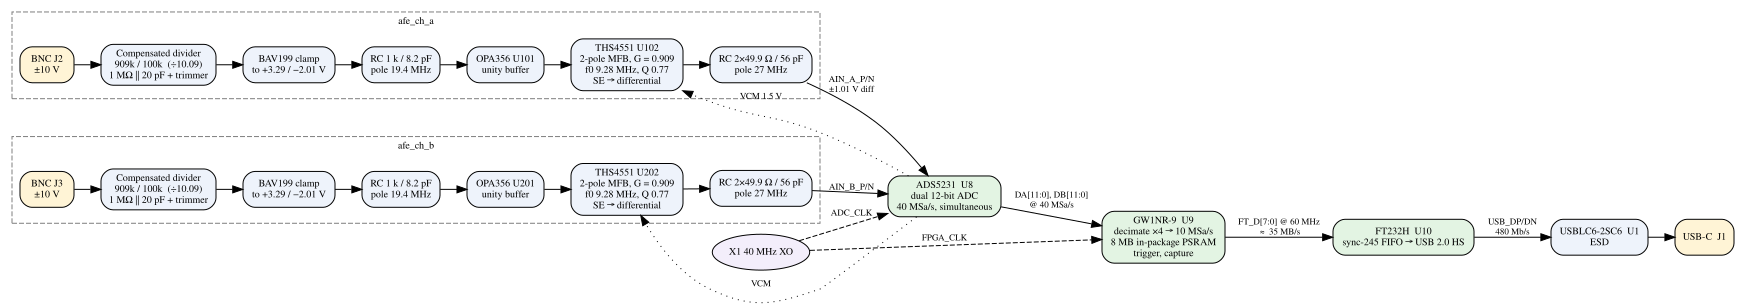

In [2]:
sig = graphviz.Digraph('signal_flow', graph_attr={'rankdir': 'LR', 'fontsize': '10', 'nodesep': '0.25', 'ranksep': '0.35'},
                       node_attr={'shape': 'box', 'style': 'rounded,filled', 'fillcolor': '#eef3fb', 'fontsize': '10'},
                       edge_attr={'fontsize': '9'})

for ch, bnc, u1, u2 in (('A', 'J2', 'U101', 'U102'), ('B', 'J3', 'U201', 'U202')):
    with sig.subgraph(name=f'cluster_afe_{ch}') as c:
        c.attr(label=f'afe_ch_{ch.lower()}', style='dashed', color='gray50')
        c.node(f'bnc{ch}', f'BNC {bnc}\n±10 V', fillcolor='#fff4d6')
        c.node(f'div{ch}', 'Compensated divider\n909k / 100k  (÷10.09)\n1 MΩ || 20 pF + trimmer')
        c.node(f'clp{ch}', 'BAV199 clamp\nto +3.29 / −2.01 V')
        c.node(f'rc1{ch}', 'RC 1 k / 8.2 pF\npole 19.4 MHz')
        c.node(f'buf{ch}', f'OPA356 {u1}\nunity buffer')
        c.node(f'fda{ch}', f'THS4551 {u2}\n2-pole MFB, G = 0.909\nf0 9.28 MHz, Q 0.77\nSE → differential')
        c.node(f'rc2{ch}', 'RC 2×49.9 Ω / 56 pF\npole 27 MHz')
        c.edges([(f'bnc{ch}', f'div{ch}'), (f'div{ch}', f'clp{ch}'), (f'clp{ch}', f'rc1{ch}'),
                 (f'rc1{ch}', f'buf{ch}'), (f'buf{ch}', f'fda{ch}'), (f'fda{ch}', f'rc2{ch}')])

sig.node('xo', 'X1 40 MHz XO', shape='ellipse', fillcolor='#f3eefb')
sig.node('adc', 'ADS5231  U8\ndual 12-bit ADC\n40 MSa/s, simultaneous', fillcolor='#e3f4e3')
sig.node('fpga', 'GW1NR-9  U9\ndecimate ×4 → 10 MSa/s\n8 MB in-package PSRAM\ntrigger, capture', fillcolor='#e3f4e3')
sig.node('ft', 'FT232H  U10\nsync-245 FIFO → USB 2.0 HS', fillcolor='#e3f4e3')
sig.node('esd', 'USBLC6-2SC6  U1\nESD')
sig.node('usb', 'USB-C  J1', fillcolor='#fff4d6')

sig.edge('rc2A', 'adc', label='AIN_A_P/N\n±1.01 V diff')
sig.edge('rc2B', 'adc', label='AIN_B_P/N')
sig.edge('adc', 'fdaA', label='VCM 1.5 V', style='dotted', constraint='false')
sig.edge('adc', 'fdaB', label='VCM', style='dotted', constraint='false')
sig.edge('xo', 'adc', label='ADC_CLK', style='dashed')
sig.edge('xo', 'fpga', label='FPGA_CLK', style='dashed')
sig.edge('adc', 'fpga', label='DA[11:0], DB[11:0]\n@ 40 MSa/s')
sig.edge('fpga', 'ft', label='FT_D[7:0] @ 60 MHz\n≈ 35 MB/s')
sig.edge('ft', 'esd', label='USB_DP/DN\n480 Mb/s')
sig.edge('esd', 'usb')
sig

### 2.2 Power distribution: USB VBUS → derived rails → consumers

All rails come from switched VBUS (`V5`). Digital loads get switching regulators; the analog
chain gets LDOs, and the clock oscillator and ADC output drivers are further isolated by ferrite
beads. The FT232H is powered from `V5` through its own internal 3.3 V regulator (as in Adafruit's
FT232H board), not from `V3V3D` — this differs from `architecture/net_plan.md` and was a driver
decision made during coding.

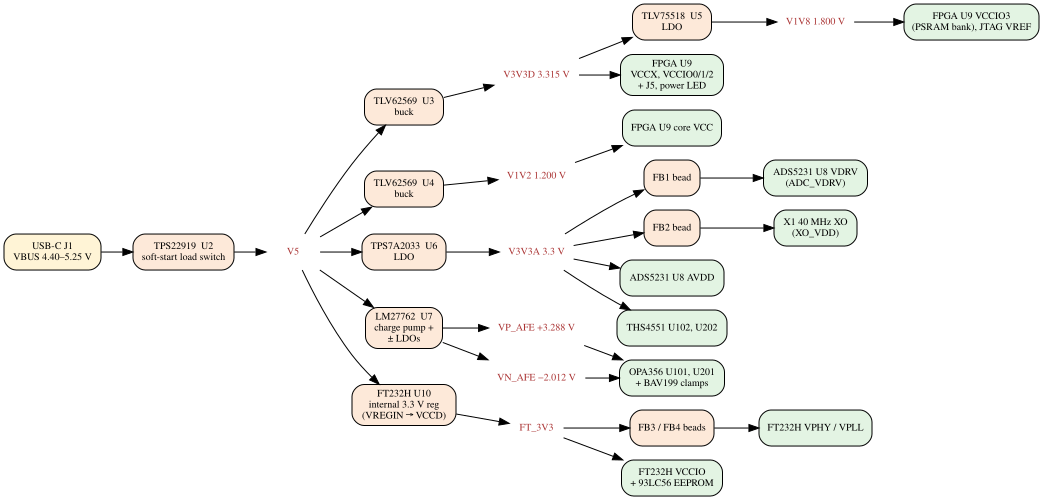

In [3]:
pwr = graphviz.Digraph('power_tree', graph_attr={'rankdir': 'LR', 'fontsize': '10', 'nodesep': '0.2', 'ranksep': '0.45'},
                       node_attr={'shape': 'box', 'style': 'rounded,filled', 'fontsize': '10'},
                       edge_attr={'fontsize': '9'})
reg = {'fillcolor': '#fde9d9'}
rail = {'shape': 'plaintext', 'style': '', 'fontcolor': '#aa3333'}
load = {'fillcolor': '#e3f4e3'}

pwr.node('J1', 'USB-C J1\nVBUS 4.40–5.25 V', fillcolor='#fff4d6')
pwr.node('U2', 'TPS22919  U2\nsoft-start load switch', **reg)
pwr.node('V5', 'V5', **rail)
pwr.edges([('J1', 'U2'), ('U2', 'V5')])

# digital
pwr.node('U3', 'TLV62569  U3\nbuck', **reg)
pwr.node('U4', 'TLV62569  U4\nbuck', **reg)
pwr.node('U5', 'TLV75518  U5\nLDO', **reg)
pwr.node('V3V3D', 'V3V3D 3.315 V', **rail)
pwr.node('V1V2', 'V1V2 1.200 V', **rail)
pwr.node('V1V8', 'V1V8 1.800 V', **rail)
pwr.edges([('V5', 'U3'), ('U3', 'V3V3D'), ('V5', 'U4'), ('U4', 'V1V2'), ('V3V3D', 'U5'), ('U5', 'V1V8')])
pwr.node('L_fpio', 'FPGA U9\nVCCX, VCCIO0/1/2\n+ J5, power LED', **load)
pwr.node('L_fcore', 'FPGA U9 core VCC', **load)
pwr.node('L_psram', 'FPGA U9 VCCIO3\n(PSRAM bank), JTAG VREF', **load)
pwr.edges([('V3V3D', 'L_fpio'), ('V1V2', 'L_fcore'), ('V1V8', 'L_psram')])

# analog
pwr.node('U6', 'TPS7A2033  U6\nLDO', **reg)
pwr.node('U7', 'LM27762  U7\ncharge pump +\n± LDOs', **reg)
pwr.node('V3V3A', 'V3V3A 3.3 V', **rail)
pwr.node('VP', 'VP_AFE +3.288 V', **rail)
pwr.node('VN', 'VN_AFE −2.012 V', **rail)
pwr.node('FB1', 'FB1 bead', **reg)
pwr.node('FB2', 'FB2 bead', **reg)
pwr.edges([('V5', 'U6'), ('U6', 'V3V3A'), ('V5', 'U7'), ('U7', 'VP'), ('U7', 'VN'),
           ('V3V3A', 'FB1'), ('V3V3A', 'FB2')])
pwr.node('L_adc', 'ADS5231 U8 AVDD', **load)
pwr.node('L_vdrv', 'ADS5231 U8 VDRV\n(ADC_VDRV)', **load)
pwr.node('L_xo', 'X1 40 MHz XO\n(XO_VDD)', **load)
pwr.node('L_fda', 'THS4551 U102, U202', **load)
pwr.node('L_buf', 'OPA356 U101, U201\n+ BAV199 clamps', **load)
pwr.edges([('V3V3A', 'L_adc'), ('FB1', 'L_vdrv'), ('FB2', 'L_xo'), ('V3V3A', 'L_fda'),
           ('VP', 'L_buf'), ('VN', 'L_buf')])

# USB bridge
pwr.node('U10reg', 'FT232H U10\ninternal 3.3 V reg\n(VREGIN → VCCD)', **reg)
pwr.node('FT3V3', 'FT_3V3', **rail)
pwr.node('FB34', 'FB3 / FB4 beads', **reg)
pwr.node('L_ftio', 'FT232H VCCIO\n+ 93LC56 EEPROM', **load)
pwr.node('L_phy', 'FT232H VPHY / VPLL', **load)
pwr.edges([('V5', 'U10reg'), ('U10reg', 'FT3V3'), ('FT3V3', 'L_ftio'), ('FT3V3', 'FB34'), ('FB34', 'L_phy')])
pwr

## 3. Component calculations

Each subsection recomputes the values in the architecture documents from the component values
used in the code, so the numbers can be checked and re-run if a part changes.

### 3.1 Signal scaling and full scale

The ADS5231 full-scale input is 2.02 Vpp differential (±1.01 V) around its 1.5 V common-mode
output. The front end's gain from BNC to ADC pins is the divider ratio times the FDA gain.

In [4]:
R_T, R_B = 909e3, 100e3          # R101 / R102
R1, R2 = 1.00e3, 909.0           # MFB input / feedback resistors (R104, R106)
ADC_FS_DIFF = 1.01               # ADS5231 ±full scale, differential volts
N_BITS = 12

k_div = R_B / (R_T + R_B)
k_fda = R2 / R1
k_total = k_div * k_fda
fs_in = ADC_FS_DIFF / k_total
lsb_in = 2 * fs_in / 2**N_BITS

print(f'divider ratio        : {k_div:.5f}  (÷{1/k_div:.3f})')
print(f'FDA gain R2/R1       : {k_fda:.4f}')
print(f'total gain           : {k_total:.5f} V/V')
print(f'full scale at BNC    : ±{fs_in:.2f} V   (margin over ±10 V: {100*(fs_in/10-1):.1f} %)')
print(f'LSB referred to BNC  : {eng(lsb_in, "V")}')
print(f'buffer swing at FS   : ±{fs_in*k_div:.3f} V')

# Worst-case FS with ADC gain error ±3.5 % and ~3 % resistor-ratio error (design_risks.md §2)
print(f'worst-case low FS    : ±{fs_in*(1-0.035-0.03):.2f} V  (must stay > 10 V)')

divider ratio        : 0.09911  (÷10.090)
FDA gain R2/R1       : 0.9090
total gain           : 0.09009 V/V
full scale at BNC    : ±11.21 V   (margin over ±10 V: 12.1 %)
LSB referred to BNC  : 5.474 mV
buffer swing at FS   : ±1.111 V
worst-case low FS    : ±10.48 V  (must stay > 10 V)


### 3.2 Compensated input divider

A resistive divider loaded by capacitance has a frequency-dependent ratio. It is flat when both
legs have the same time constant, `R_T·C_T = R_B·C_B`. That is also what lets a 10× probe (itself a
9 MΩ ‖ C divider) be compensated against this input.

`C_B` is the sum of C102 (150 pF), C103 (15 pF), C_S (8.2 pF, seen through R_S = 1 kΩ, which is
small against the ~90 kΩ node impedance), ~3 pF of board parasitics, and the JZ300 trimmer
(5.5–30 pF).

In [5]:
C_T = 22e-12                     # C101
C_B_fixed = 150e-12 + 15e-12     # C102 + C103
C_S = 8.2e-12                    # C105 (behind R103)
C_par = 3e-12                    # board parasitics (estimate)
TRIM_MIN, TRIM_MAX = 5.5e-12, 30e-12   # JZ300

C_B_needed = R_T * C_T / R_B
trim_nom = C_B_needed - C_B_fixed - C_S - C_par

# Worst-case spread of the fixed parts: C_T ±1 % (×R_T/R_B), C_B1/C_B2 ±1 %, parasitics ±2 pF
spread = (R_T / R_B) * 0.01 * C_T + 0.01 * C_B_fixed + 2e-12
print(f'C_B needed            : {eng(C_B_needed, "F")}')
print(f'trimmer nominal       : {eng(trim_nom, "F")}')
print(f'trimmer needed range  : {eng(trim_nom - spread, "F")} … {eng(trim_nom + spread, "F")}'
      f'   (JZ300: {eng(TRIM_MIN, "F")} … {eng(TRIM_MAX, "F")})')
print(f'headroom at top       : {eng(TRIM_MAX - (trim_nom + spread), "F")}  <-- thin; ±5 % caps would overrun it')

R_in = R_T + R_B
C_in = C_T * (C_B_needed) / (C_T + C_B_needed)
print(f'input impedance       : {eng(R_in, "Ω")} ‖ {eng(C_in, "F")}  (+ BNC/trace ≈ 2 pF)')

# JZ300 TC is −1500 ± 1000 ppm/°C → drift of the trimmer over a 25 °C swing
for tc in (-500e-6, -2500e-6):
    print(f'trimmer drift @ {tc*1e6:.0f} ppm/°C, ΔT = 25 °C : {eng(trim_nom*tc*25, "F")}')

C_B needed            : 200 pF
trimmer nominal       : 23.78 pF
trimmer needed range  : 18.13 pF … 29.43 pF   (JZ300: 5.5 pF … 30 pF)
headroom at top       : 570.2 fF  <-- thin; ±5 % caps would overrun it
input impedance       : 1.009 MΩ ‖ 19.82 pF  (+ BNC/trace ≈ 2 pF)
trimmer drift @ -500 ppm/°C, ΔT = 25 °C : -297.3 fF
trimmer drift @ -2500 ppm/°C, ΔT = 25 °C : -1.486 pF


Step response of the divider (what you see when adjusting the trimmer with a 1 kHz square wave).
With `C_B` total, the edge ratio is `C_T/(C_T+C_B)` and the settled ratio is `R_B/(R_T+R_B)`;
the transition between them has time constant `(R_T‖R_B)(C_T+C_B)`.

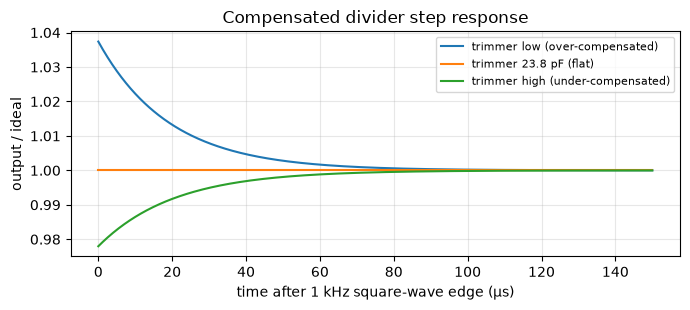

In [6]:
t = np.linspace(0, 150e-6, 600)
fig, ax = plt.subplots(figsize=(7, 3.2))
for trim, lbl in ((trim_nom - 8e-12, 'trimmer low (over-compensated)'),
                  (trim_nom, f'trimmer {trim_nom*1e12:.1f} pF (flat)'),
                  (trim_nom + 5e-12, 'trimmer high (under-compensated)')):
    C_Bt = C_B_fixed + C_S + C_par + trim
    v0 = C_T / (C_T + C_Bt)
    tau = (R_T * R_B / (R_T + R_B)) * (C_T + C_Bt)
    v = k_div + (v0 - k_div) * np.exp(-t / tau)
    ax.plot(t * 1e6, v / k_div, label=lbl)
ax.set_xlabel('time after 1 kHz square-wave edge (µs)')
ax.set_ylabel('output / ideal')
ax.set_title('Compensated divider step response')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3.3 Overvoltage protection (±30 V)

The BAV199 dual diode clamps the divider node to the buffer rails. Because the divider already
divides by 10, the fault current is limited by R_T, not by a series resistor.

In [7]:
V_fault = 30.0
VP_AFE, VN_AFE = 3.288, -2.012
V_F = 0.5          # BAV199 forward drop at µA currents (approximate)

v_div_fault = V_fault * k_div
print(f'divider node at ±30 V : ±{v_div_fault:.2f} V (unclamped)')
print(f'clamp window          : {VN_AFE - V_F:.2f} … {VP_AFE + V_F:.2f} V')
print(f'fault current (R_T)   : {eng(V_fault / R_T, "A")}')
print(f'R_T dissipation       : {eng(V_fault**2 / R_T, "W")}')
print(f'OPA356 input CM limit : {VN_AFE - 0.1:.2f} … {VP_AFE - 1.5:.2f} V  vs normal peak ±{fs_in*k_div:.3f} V')

divider node at ±30 V : ±2.97 V (unclamped)
clamp window          : -2.51 … 3.79 V
fault current (R_T)   : 33 µA
R_T dissipation       : 990.1 µW
OPA356 input CM limit : -2.11 … 1.79 V  vs normal peak ±1.111 V


### 3.4 Anti-aliasing filter

The ADC samples at 40 MSa/s and the FPGA decimates by 4 to 10 MSa/s. Anything the analog filter
passes near 40 MHz ± 5 MHz folds straight into the 0–5 MHz output band *before* the digital
filter can act, so the analog filter has to attenuate at the **alias edge, 35 MHz**, while
staying flat to ~4–5 MHz. Content between 5 and 35 MHz lands outside the output band after
sampling and is removed by the decimation filter.

The filter has four poles at distinct nodes:

| Stage | Parts (ch A) | Type |
|---|---|---|
| Buffer input RC | R103 1 kΩ, C105 8.2 pF | real pole |
| THS4551 MFB | R104/R105 1 kΩ (R1), R106/R107 909 Ω (R2), R108/R109 499 Ω (R3), C108 27 pF differential (C1), C109/C110 12 pF (C2) | complex pole pair |
| ADC input RC | R110/R111 49.9 Ω, C113 56 pF + ~3 pF ADC input | real pole |

For the MFB, the differential capacitor C108 appears as 2 × 27 pF to the virtual midpoint in each
half-circuit. Standard MFB low-pass relations per half-circuit:

$$ f_0 = \frac{1}{2\pi\sqrt{R_2 R_3 C_1 C_2}}, \qquad
   Q = \frac{\sqrt{R_2 R_3 C_1 C_2}}{C_2\,(R_2 + R_3 + R_2 R_3 / R_1)}, \qquad
   H_0 = -\frac{R_2}{R_1} $$

In [8]:
AAF = dict(R_T=R_T, C_T=C_T, R_B=R_B, C_B=C_B_fixed + trim_nom + C_par,
           R_S=1e3, C_S=8.2e-12,
           R1=1e3, R2=909.0, R3=499.0, C1=27e-12, C2=12e-12,
           R_O=49.9, C_O=56e-12 + 3e-12)

def mfb_f0_q(p):
    C1h = 2 * p['C1']                          # differential cap seen per half-circuit
    tau = np.sqrt(p['R2'] * p['R3'] * C1h * p['C2'])
    f0 = 1 / (2 * np.pi * tau)
    Q = tau / (p['C2'] * (p['R2'] + p['R3'] + p['R2'] * p['R3'] / p['R1']))
    return f0, Q

f0, Q = mfb_f0_q(AAF)
f_rs = 1 / (2 * np.pi * AAF['R_S'] * AAF['C_S'])
f_ro = 1 / (2 * np.pi * 2 * AAF['R_O'] * AAF['C_O'])
print(f'buffer-input pole  : {eng(f_rs, "Hz")}')
print(f'MFB f0, Q          : {eng(f0, "Hz")}, Q = {Q:.3f}   (Butterworth Q = 0.707)')
print(f'ADC-input RC pole  : {eng(f_ro, "Hz")}')

buffer-input pole  : 19.41 MHz
MFB f0, Q          : 9.283 MHz, Q = 0.767   (Butterworth Q = 0.707)
ADC-input RC pole  : 27.03 MHz


Two models of the complete chain from BNC to ADC pins:

1. **Ideal cascade** — the product of the three stage responses above (ideal amplifiers, no
   loading between stages).
2. **Nodal model** — a full node-voltage (MNA) solution of the circuit as wired in the code,
   including the divider, both halves of the MFB, the OPA356 (GBW ≈ 200 MHz) and the THS4551
   (GBW 135 MHz, A₀ = 100 dB) as single-pole amplifiers. The FDA is modelled by
   `Vop − Von = A(s)·(V(FIP) − V(FIN))` and `Vop + Von = 0` (AC, VCM held constant).

In [9]:
def h_cascade(f, p=AAF):
    s = 2j * np.pi * np.asarray(f)
    f0, Q = mfb_f0_q(p); w0 = 2 * np.pi * f0
    return (1 / (1 + s * p['R_S'] * p['C_S'])
            / (1 + s / (w0 * Q) + (s / w0)**2)
            / (1 + s * 2 * p['R_O'] * p['C_O']))


def h_nodal(f, p=AAF, gbw_buf=200e6, gbw_fda=135e6, a0=1e5):
    # Node order: DIV, BUF_IN, BUF_OUT, XP, XN, FIP, FIN, FOP, FON, AIN_P, AIN_N
    DIV, BI, BO, XP, XN, FIP, FIN, FOP, FON, AP, AN = range(11)
    GND, SRC = -1, -2
    s = 2j * np.pi * f
    Y = np.zeros((11, 11), complex); b = np.zeros(11, complex)

    def y(i, j, yy):                      # admittance from node i to node j (KCL row i)
        Y[i, i] += yy
        if j >= 0:
            Y[i, j] -= yy
        elif j == SRC:
            b[i] += yy                    # 1 V source at the BNC

    yT, yB, yS = 1/p['R_T'] + s*p['C_T'], 1/p['R_B'] + s*p['C_B'], 1/p['R_S']
    y(DIV, SRC, yT); y(DIV, GND, yB); y(DIV, BI, yS)
    y(BI, DIV, yS); y(BI, GND, s*p['C_S'])
    Y[BO, BO], Y[BO, BI] = 1, -1 / (1 + s / (2*np.pi*gbw_buf))          # OPA356 follower
    for x, fi, fo_same, fo_fb, src in ((XP, FIP, FOP, FON, BO), (XN, FIN, FON, FOP, GND)):
        other = XN if x == XP else XP
        y(x, src, 1/p['R1']); y(x, other, s*p['C1']); y(x, fi, 1/p['R3']); y(x, fo_fb, 1/p['R2'])
        y(fi, x, 1/p['R3']); y(fi, fo_fb, s*p['C2'])
    A = a0 / (1 + s * a0 / (2*np.pi*gbw_fda))
    Y[FOP, :] = 0; Y[FOP, FOP], Y[FOP, FON], Y[FOP, FIP], Y[FOP, FIN] = 1, -1, -A, A
    Y[FON, :] = 0; Y[FON, FOP], Y[FON, FON] = 1, 1
    y(AP, FOP, 1/p['R_O']); y(AP, AN, s*p['C_O'])
    y(AN, FON, 1/p['R_O']); y(AN, AP, s*p['C_O'])
    v = np.linalg.solve(Y, b)
    return v[AP] - v[AN]


h_nodal_v = np.vectorize(h_nodal, excluded={'p'})
H0 = abs(h_nodal(1.0))
print(f'nodal DC gain: {H0:.5f} V/V  (hand calc {k_total:.5f})')

def db(h):
    return 20 * np.log10(np.abs(h))

def f_3db(fn):
    return brentq(lambda x: db(fn(x)) + 3, 1e6, 3e7)

hn = lambda f: h_nodal(f) / H0
print(f'-3 dB: cascade {eng(f_3db(h_cascade), "Hz")}, nodal {eng(f_3db(hn), "Hz")}')
print(f'\n{"f":>9}  {"cascade":>8}  {"nodal":>8}')
for f in (1e6, 4e6, 5e6, 10e6, 20e6, 35e6, 40e6):
    print(f'{eng(f, "Hz"):>9}  {db(h_cascade(f)):7.2f}   {db(hn(f)):7.2f}  dB')

nodal DC gain: 0.09009 V/V  (hand calc 0.09009)
-3 dB: cascade 8.699 MHz, nodal 8.378 MHz

        f   cascade     nodal
    1 MHz    -0.00      0.01  dB
    4 MHz    -0.18     -0.06  dB
    5 MHz    -0.41     -0.29  dB
   10 MHz    -4.58     -5.27  dB
   20 MHz   -18.29    -19.76  dB
   35 MHz   -33.55    -35.24  dB
   40 MHz   -37.55    -39.34  dB


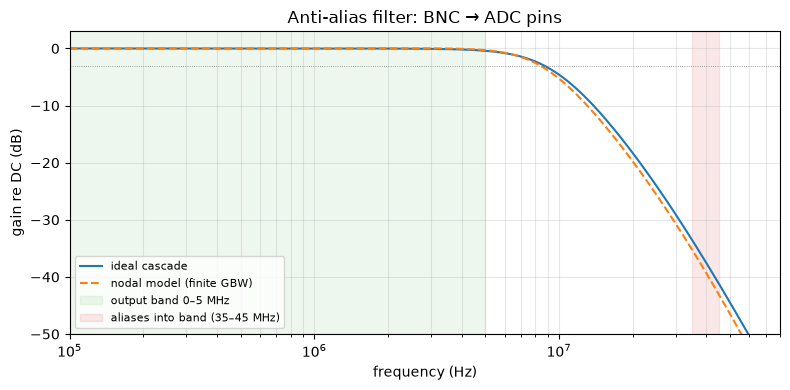

In [10]:
f = np.logspace(5, np.log10(80e6), 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(f, db(h_cascade(f)), label='ideal cascade')
ax.semilogx(f, db(h_nodal_v(f) / H0), '--', label='nodal model (finite GBW)')
ax.axvspan(1e5, 5e6, color='tab:green', alpha=0.08, label='output band 0–5 MHz')
ax.axvspan(35e6, 45e6, color='tab:red', alpha=0.10, label='aliases into band (35–45 MHz)')
ax.axhline(-3, color='gray', lw=0.6, ls=':')
ax.set_xlim(1e5, 80e6); ax.set_ylim(-50, 3)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('gain re DC (dB)')
ax.set_title('Anti-alias filter: BNC → ADC pins')
ax.grid(which='both', alpha=0.3); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

Tolerance check: Monte-Carlo over the filter parts (R ±1 %, C ±5 % C0G, independent for each
half of the differential MFB) using the nodal model.

In [11]:
rng = np.random.default_rng(1)
keys_r = ('R1', 'R2', 'R3', 'R_O', 'R_S')
keys_c = ('C1', 'C2', 'C_O', 'C_S')
res = []
for _ in range(200):
    p = dict(AAF)
    for k in keys_r:
        p[k] = AAF[k] * (1 + rng.uniform(-0.01, 0.01))
    for k in keys_c:
        p[k] = AAF[k] * (1 + rng.uniform(-0.05, 0.05))
    h0 = abs(h_nodal(1.0, p))
    g = lambda x: h_nodal(x, p) / h0
    res.append((f_3db(g), db(g(5e6)), db(g(35e6)), max(db(g(x)) for x in np.linspace(1e5, 5e6, 20))))
res = np.array(res)
for i, name, unit in ((0, '-3 dB frequency', 'MHz'), (1, 'gain @ 5 MHz', 'dB'),
                      (2, 'gain @ 35 MHz', 'dB'), (3, 'peaking in 0–5 MHz', 'dB')):
    col = res[:, i] / (1e6 if unit == 'MHz' else 1)
    print(f'{name:20s}: min {col.min():7.2f}  mean {col.mean():7.2f}  max {col.max():7.2f}  {unit}')

-3 dB frequency     : min    8.00  mean    8.39  max    8.75  MHz
gain @ 5 MHz        : min   -0.52  mean   -0.28  max   -0.07  dB
gain @ 35 MHz       : min  -36.34  mean  -35.22  max  -34.29  dB
peaking in 0–5 MHz  : min   -0.01  mean    0.03  max    0.12  dB


**Result and caveats.**

- The filter gives roughly **33–35 dB of rejection at the 35 MHz alias edge** and a −3 dB
  bandwidth near 8.3–8.7 MHz, depending on the amplifier model. That is about 5–6 bits of
  alias suppression, well short of the 74 dB a 12-bit converter could resolve. The design accepts
  this as a documented limit: out-of-band energy at 35–45 MHz aliases with only ~33 dB rejection.
- `architecture/design_risks.md` quotes −3 dB at 8.86 MHz and −32.1 dB at 35 MHz from its own
  node model. The models here land within ~0.5 MHz / ~2 dB of that; the difference is in the
  amplifier and parasitic assumptions (unknown for the original model). Neither has been checked
  against SPICE or measurement.
- The ADC input capacitance (~3 pF here) is an assumption; it is not in the ADS5231 summary.
- In-band droop (≈ 0.3–0.4 dB at 5 MHz) is meant to be equalised in the FPGA decimation FIR
  (planned: pass 0–4 MHz ≤ 0.1 dB ripple, stop ≥ 60 dB from 6 MHz). That HDL does not exist yet.

### 3.5 Data rates, capture depth and USB upload

In [12]:
F_ADC = 40e6; DECIM = 4; CH = 2; BYTES = 2      # 12-bit samples stored as 16-bit words
PSRAM = 8 * 2**20                                # 64 Mbit
USB_RATE = 35e6                                  # FT232H sync-FIFO, practical

f_out = F_ADC / DECIM
rate_store = f_out * CH * BYTES
print(f'ADC → FPGA          : 2 × 12 bit @ {eng(F_ADC, "Sa/s")} = {eng(F_ADC*24, "b/s")} parallel')
print(f'output rate         : {eng(f_out, "Sa/s")} per channel')
print(f'PSRAM write rate    : {eng(rate_store, "B/s")}')
print(f'capture depth       : {PSRAM / rate_store:.3f} s at 10 MSa/s (need ≥ 0.1 s)')
print(f'raw 40 MSa/s depth  : {PSRAM / (F_ADC*CH*BYTES):.3f} s')
need = 0.1 * rate_store
print(f'upload of 0.1 s     : {eng(need, "B")} in {need/USB_RATE:.3f} s at {eng(USB_RATE, "B/s")}')

ADC → FPGA          : 2 × 12 bit @ 40 MSa/s = 960 Mb/s parallel
output rate         : 10 MSa/s per channel
PSRAM write rate    : 40 MB/s
capture depth       : 0.210 s at 10 MSa/s (need ≥ 0.1 s)
raw 40 MSa/s depth  : 0.052 s
upload of 0.1 s     : 4 MB in 0.114 s at 35 MB/s


### 3.6 Regulator output voltages

TLV62569 bucks: `Vout = 0.6 V · (1 + R_top/R_bot)`. LM27762: positive side
`VP = 1.2 V · (R_top + R_bot)/R_bot`, negative side `VN = −1.22 V · (R_top + R_bot)/R_bot`
(datasheet requires R_bot ≥ 50 kΩ). Worst case includes the reference tolerance and 1 % resistors.

In [13]:
def divider_out(vref, r_top, r_bot, sign=1, vref_tol=0.02, r_tol=0.01):
    nom = vref * (r_top + r_bot) / r_bot
    hi = vref * (1 + vref_tol) * (1 + r_top * (1 + r_tol) / (r_bot * (1 - r_tol)))
    lo = vref * (1 - vref_tol) * (1 + r_top * (1 - r_tol) / (r_bot * (1 + r_tol)))
    return sign * nom, sign * lo, sign * hi

rails = [
    ('V3V3D (U3, R3/R4)', 0.6, 100e3, 22.1e3, 1, 0.02, 'FPGA VCCIO, logic 3.3 V'),
    ('V1V2  (U4, R5/R6)', 0.6, 100e3, 100e3, 1, 0.02, 'GW1NR VCC 1.14–1.26 V'),
    ('VP_AFE (U7, R8/R9)', 1.2, 174e3, 100e3, 1, 0.015, 'OPA356 V+'),
    ('VN_AFE (U7, R10/R11)', 1.22, 64.9e3, 100e3, -1, 0.015, 'OPA356 V−'),
]
out = {}
for name, vref, rt, rb, sg, tol, note in rails:
    nom, lo, hi = divider_out(vref, rt, rb, sg, tol)
    out[name.split()[0]] = (nom, lo, hi)
    print(f'{name:22s} {nom:+.3f} V  ({lo:+.3f} … {hi:+.3f})   {note}')
print('V3V3A (U6, fixed)       +3.300 V;  V1V8 (U5, fixed) +1.800 V')

vp_hi, vn_lo = out['VP_AFE'][2], out['VN_AFE'][2]
print(f'\nOPA356 worst total supply: {vp_hi - vn_lo:.3f} V (max 5.5 V)')

V3V3D (U3, R3/R4)      +3.315 V  (+3.196 … +3.437)   FPGA VCCIO, logic 3.3 V
V1V2  (U4, R5/R6)      +1.200 V  (+1.164 … +1.236)   GW1NR VCC 1.14–1.26 V
VP_AFE (U7, R8/R9)     +3.288 V  (+3.198 … +3.380)   OPA356 V+
VN_AFE (U7, R10/R11)   -2.012 V  (-1.966 … -2.058)   OPA356 V−
V3V3A (U6, fixed)       +3.300 V;  V1V8 (U5, fixed) +1.800 V

OPA356 worst total supply: 5.438 V (max 5.5 V)


### 3.7 Power budget (as built)

Load currents are from `architecture/design_risks.md`; many are **estimates** (FPGA core and I/O,
FT232H, PSRAM) pending the Gowin power estimator. That table assumed the FT232H ran from `V3V3D`;
the code feeds it from `V5` through its internal regulator, so it is recomputed here.
Linear regulators draw their output current from V5; bucks draw `P_out / η`.

In [14]:
V5_TYP, V5_MAX = 5.0, 5.25
# (name, kind, V_out, I_typ, I_max, eff_typ, eff_max)
loads = [
    ('V3V3A  TPS7A2033 LDO',       'ldo',  3.3,   110.2e-3, 139.1e-3, None, None),
    ('VP/VN_AFE LM27762 (VIN)',    'ldo',  None,  38.2e-3,  54.0e-3,  None, None),
    ('FT232H internal reg',        'ldo',  3.3,   60.5e-3,  81.0e-3,  None, None),
    ('V3V3D  TLV62569 buck',       'buck', 3.315, 49.4e-3,  109.9e-3, 0.90, 0.85),
    ('V1V2   TLV62569 buck',       'buck', 1.2,   50e-3,    150e-3,   0.80, 0.75),
]
tot_t = tot_m = 0
print(f'{"rail":28s} {"typ mW":>8} {"max mW":>8}')
for name, kind, v, it, im, et, em in loads:
    if kind == 'ldo':
        pt, pm = V5_TYP * it, V5_MAX * im
    else:
        pt, pm = v * it / et, v * 1.02 * im / em
    tot_t += pt; tot_m += pm
    print(f'{name:28s} {pt*1e3:8.0f} {pm*1e3:8.0f}')
p_sw = (tot_m / 4.75)**2 * 0.09
tot_m += p_sw
print(f'{"TPS22919 switch loss":28s} {0:8.0f} {p_sw*1e3:8.0f}')
print(f'{"TOTAL":28s} {tot_t*1e3:8.0f} {tot_m*1e3:8.0f}   → USB-C chosen (> 2.0 W worst case)')
print(f'worst-case VBUS current at 4.75 V: {tot_m/4.75*1e3:.0f} mA (legacy port limit 500 mA)')

# LDO dissipation — the hottest small part
i6 = 139.1e-3
p6 = (V5_MAX - 3.3) * i6
print(f'\nTPS7A2033 dissipation: {p6*1e3:.0f} mW → ΔT ≈ {p6*200:.0f} °C at ~200 °C/W (est.) → '
      f'Tj ≈ {50 + p6*200:.0f} °C at 50 °C ambient (limit 125 °C)')

rail                           typ mW   max mW
V3V3A  TPS7A2033 LDO              551      730
VP/VN_AFE LM27762 (VIN)           191      284
FT232H internal reg               302      425
V3V3D  TLV62569 buck              182      437
V1V2   TLV62569 buck               75      245
TPS22919 switch loss                0       18
TOTAL                            1301     2139   → USB-C chosen (> 2.0 W worst case)
worst-case VBUS current at 4.75 V: 450 mA (legacy port limit 500 mA)

TPS7A2033 dissipation: 271 mW → ΔT ≈ 54 °C at ~200 °C/W (est.) → Tj ≈ 104 °C at 50 °C ambient (limit 125 °C)


### 3.8 Miscellaneous values

In [15]:
# FT232H 12 MHz crystal load caps (CL = 20 pF is UNVERIFIED — distributor field only)
CL, C_stray = 20e-12, 3.5e-12
c_load = 2 * (CL - C_stray)
print(f'Y1 load caps: 2·(CL − Cstray) = {eng(c_load, "F")} → 33 pF (C47, C48); '
      f'actual CL = {eng(33e-12/2 + C_stray, "F")}')

# LEDs
for ref, v in (('D1', 3.315), ('D2/D3', 3.3)):
    print(f'{ref} current: ({v} − 2.0 V) / 1 kΩ = {eng((v - 2.0) / 1e3, "A")}')

# Clock levels: XO VOH/VOL vs ADS5231 CLK thresholds
VOH, VOL, VIH, VIL = 0.9 * 3.3, 0.1 * 3.3, 2.2, 0.6
print(f'XO VOH {VOH:.2f} V ≥ VIH {VIH} V: {VOH >= VIH};  VOL {VOL:.2f} V ≤ VIL {VIL} V: {VOL <= VIL}')

# Clock-jitter budget for 12-bit-class SNR at 5 MHz
for tj in (1e-12, 3e-12, 10e-12, 50e-12):
    print(f'  jitter {tj*1e12:4.0f} ps rms → SNR limit {-20*np.log10(2*np.pi*5e6*tj):.1f} dB at 5 MHz')

# ADC bias resistor
print(f'ISET R12 = 56.2 kΩ (datasheet value); USB PHY REF R25 = 12.0 kΩ 1 % (FT232H requirement)')

Y1 load caps: 2·(CL − Cstray) = 33 pF → 33 pF (C47, C48); actual CL = 20 pF
D1 current: (3.315 − 2.0 V) / 1 kΩ = 1.315 mA
D2/D3 current: (3.3 − 2.0 V) / 1 kΩ = 1.3 mA
XO VOH 2.97 V ≥ VIH 2.2 V: True;  VOL 0.33 V ≤ VIL 0.6 V: True
  jitter    1 ps rms → SNR limit 90.1 dB at 5 MHz
  jitter    3 ps rms → SNR limit 80.5 dB at 5 MHz
  jitter   10 ps rms → SNR limit 70.1 dB at 5 MHz
  jitter   50 ps rms → SNR limit 56.1 dB at 5 MHz
ISET R12 = 56.2 kΩ (datasheet value); USB PHY REF R25 = 12.0 kΩ 1 % (FT232H requirement)


## 4. Part sourcing

All parts were sourced from JLCPCB/LCSC stock (`sourcing/sourced_bom.csv`). The critical ICs:

In [16]:
import pandas as pd
bom = pd.read_csv(PROJ / 'sourcing' / 'sourced_bom.csv')
ics = bom[bom.refdes.str.match(r'^(U|X|Y|J)\d')][['refdes', 'mpn', 'lcsc', 'package', 'tier', 'stock', 'notes']]
display(ics.style.hide(axis='index'))
print(bom.tier.value_counts().to_string())

refdes,mpn,lcsc,package,tier,stock,notes
J1,TYPE-C-31-M-12,C165948,USB-C SMD 16P,Extended,89676,"USB 2.0 only; symbol corrected to Connector:USB_C_Receptacle_USB2.0_16P to match usb_power_in.py pin-by-number map; footprint unchanged, exact vendor match"
U1,USBLC6-2SC6,C2827654,SOT-23-6,Extended,106827,manufacturer TECH PUBLIC
U2,TPS22919DCKR,C2149796,SC-70-6,Extended,68311,generated symbol confirmed in usb_power_in.py
U3,TLV62569DBVR,C141836,SOT-23-5,Extended,241177,V3V3D buck
U4,TLV62569DBVR,C141836,SOT-23-5,Extended,241177,V1V2 buck
U5,TLV75518PDBVR,C2877863,SOT-23-5,Extended,9868,V1V8 LDO
U6,TPS7A2033PDBVR,C2862740,SOT-23-5,Extended,230939,V3V3A analog LDO; generated symbol confirmed in power_analog.py
U7,LM27762DSSR,C473398,WSON-12-EP(2x3),Extended,40112,"bipolar AFE rails; custom-fp flag retired, footprint resolves in standard KiCad library and matches power_analog.py"
J2,KH-BNC50-3511,C2837587,THT right-angle BNC,Extended,5979,"ch A input BNC; custom-fp flag retired, project-local footprint generated and wired in afe_ch_a.py"
U101,OPA356AIDBVR,C183100,SOT-23-5,Extended,1382,ch A input buffer


tier
Extended     73
Basic        56
Preferred     2


## 5. Design blocks (SKiDL)

Each block is an `@SubCircuit` function whose arguments are its interface nets. Nets local to a
block are created inside it. Blocks never import each other; the top-level assembly (§6) creates
the interface nets and wires the blocks together. Ref designators follow the architecture's
numbering (1xx = channel A, 2xx = channel B).

Execution order below follows the power path, then the signal path.

### 5.1 USB power input

USB-C receptacle (USB 2.0 data only), CC pull-downs so any USB-C source supplies default power, USBLC6 ESD on D+/D−/VBUS, and a TPS22919 load switch whose controlled rise keeps the inrush from the >100 µF of downstream capacitance within USB limits. Produces `V5`.

In [17]:
"""USB Power In — USB-C receptacle (USB 2.0), D+/D-/VBUS ESD array, soft-start load switch
Block from: architecture/block_diagram.md (usb_power_in)
Interface nets: V5, USB_DP, USB_DN, GND
"""


@SubCircuit
def usb_power_in(v5, usb_dp, usb_dn, gnd):
    """USB-C sink input.

    J1 TYPE-C-31-M-12 (USB 2.0 only): CC1/CC2 each Rd 5.1k to GND (default-USB sink).
    D+ (A6/B6) and D- (A7/B7) are paralleled on the connector and brought out as
    usb_dp / usb_dn through U1 USBLC6-2SC6 ESD (pass-through pads 1/6 and 3/4).
    Raw VBUS (local net) -> U2 TPS22919 soft-start switch -> v5 (U2 drives v5).
    U2.ON tied to VBUS (4.4-5.25 V >= VIH 1.0 V); QOD tied to VOUT (24 ohm discharge).
    C1 4.7 uF on VBUS keeps pre-switch capacitance < 10 uF (USB inrush rule).
    SBU1/SBU2 unused -> NC. Shell and GND pins -> gnd.
    """
    # --- local nets (net_plan.md: VBUS, CC1, CC2) ---
    vbus = Net('VBUS')
    vbus.drive = POWER          # sole source is the connector (passive pins)
    cc1 = Net('CC1')
    cc2 = Net('CC2')

    # --- J1 USB-C receptacle (pins by number; matches HRO footprint pads) ---
    J1 = Part('Connector', 'USB_C_Receptacle_USB2.0_16P', ref='J1',
              value='TYPE-C-31-M-12',
              footprint='Connector_USB:USB_C_Receptacle_HRO_TYPE-C-31-M-12')
    J1['A4', 'A9', 'B4', 'B9'] += vbus
    J1['A1', 'A12', 'B1', 'B12', 'S1'] += gnd
    J1['A5'] += cc1
    J1['B5'] += cc2
    J1['A6', 'B6'] += usb_dp
    J1['A7', 'B7'] += usb_dn
    J1['A8', 'B8'] += NC        # SBU1/SBU2 unused

    # --- CC Rd pull-downs (5.1k, sink / default USB power) ---
    R1 = Part('Device', 'R', ref='R1', value='5.1k',
              footprint='Resistor_SMD:R_0603_1608Metric')
    R2 = Part('Device', 'R', ref='R2', value='5.1k',
              footprint='Resistor_SMD:R_0603_1608Metric')
    cc1 & R1 & gnd
    cc2 & R2 & gnd

    # --- U1 USBLC6-2SC6 ESD: I/O1 (1,6) = D+, I/O2 (3,4) = D-, VBUS clamp on raw VBUS ---
    U1 = Part('Power_Protection', 'USBLC6-2SC6', ref='U1', value='USBLC6-2SC6',
              footprint='Package_TO_SOT_SMD:SOT-23-6')
    U1[1, 6] += usb_dp
    U1[3, 4] += usb_dn
    U1[5] += vbus
    U1[2] += gnd

    # --- U2 TPS22919 load switch: 1 IN, 2 GND, 3 ON, 4 NC, 5 QOD, 6 VOUT ---
    U2 = Part('dual_adc_usb', 'TPS22919DCKR', ref='U2', value='TPS22919DCKR',
              footprint='Package_TO_SOT_SMD:SOT-363_SC-70-6')
    U2[1] += vbus
    U2[3] += vbus               # always on while VBUS present
    U2[2] += gnd
    U2[4] += NC                 # datasheet: leave floating
    U2[5] += v5                 # QOD -> VOUT: internal quick discharge
    U2[6] += v5

    # --- bulk / HF capacitors ---
    C1 = Part('Device', 'C', ref='C1', value='4.7uF',
              footprint='Capacitor_SMD:C_0603_1608Metric')   # VBUS, pre-switch
    C2 = Part('Device', 'C', ref='C2', value='10uF',
              footprint='Capacitor_SMD:C_0603_1608Metric')   # V5 bulk
    C3 = Part('Device', 'C', ref='C3', value='100nF',
              footprint='Capacitor_SMD:C_0402_1005Metric')   # V5 HF
    vbus & C1 & gnd
    v5 & C2 & gnd
    v5 & C3 & gnd

### 5.2 Digital power

Two TLV62569 bucks make 3.3 V (logic, FPGA I/O) and 1.2 V (FPGA core). A TLV75518 LDO off 3.3 V makes 1.8 V for FPGA bank 3, which also powers the in-package PSRAM. Feedback values are checked in §3.6.

In [18]:
"""Power Digital — 3.3 V and 1.2 V TLV62569 bucks, 1.8 V TLV75518P LDO, power LED
Block from: architecture/block_diagram.md (power_digital)
Interface nets: V5, V3V3D, V1V2, V1V8, GND
"""


@SubCircuit
def power_digital(v5, v3v3d, v1v2, v1v8, gnd):
    """Digital supply rails from V5.

    U3 TLV62569 buck: V5 -> v3v3d, 0.6 V x (1 + 100k/22.1k) = 3.315 V (R3/R4), L1 2.2 uH.
    U4 TLV62569 buck: V5 -> v1v2,  0.6 V x (1 + 100k/100k)  = 1.200 V (R5/R6), L2 2.2 uH.
    U3/U4 EN tied to V5 (>= 4.40 V vs VIH <= 1.2 V).
    U5 TLV75518P fixed LDO: v3v3d -> v1v8 (IN and EN on v3v3d; FPGA bank 3 / PSRAM).
    D1 green power LED from v3v3d through R7 1k.
    v3v3d and v1v2 are driven only through inductors (passive) -> assembler must
    set .drive = POWER on them. v1v8 is driven by U5.OUT.
    FT232H is fed from V5 (driver decision); no FT232H load assumed on v3v3d.
    """
    # --- local nets (net_plan.md: SW33, FB33, SW12, FB12, PWR_LED) ---
    sw33, fb33 = Net('SW33'), Net('FB33')
    sw12, fb12 = Net('SW12'), Net('FB12')
    pwr_led = Net('PWR_LED')

    r_t = Part('Device', 'R', dest=TEMPLATE, footprint='Resistor_SMD:R_0603_1608Metric')
    buck_t = Part('Regulator_Switching', 'TLV62569DBV', dest=TEMPLATE,
                  value='TLV62569DBVR', footprint='Package_TO_SOT_SMD:SOT-23-5')
    l_t = Part('Device', 'L', dest=TEMPLATE, value='2.2uH',
               footprint='Inductor_SMD:L_Changjiang_FNR3015S')

    # --- U3: 3.3 V digital buck (pins: 1 EN, 2 GND, 3 SW, 4 VIN, 5 FB) ---
    U3 = buck_t(ref='U3')
    L1 = l_t(ref='L1')
    U3['VIN', 'EN'] += v5
    U3['GND'] += gnd
    U3['SW'] += sw33
    U3['FB'] += fb33
    sw33 & L1 & v3v3d
    R3 = r_t(ref='R3', value='100k')      # FB top
    R4 = r_t(ref='R4', value='22.1k')     # FB bottom
    v3v3d & R3 & fb33 & R4 & gnd
    C4 = Part('Device', 'C', ref='C4', value='10uF',
              footprint='Capacitor_SMD:C_0603_1608Metric')   # U3 input
    C5 = Part('Device', 'C', ref='C5', value='22uF',
              footprint='Capacitor_SMD:C_0805_2012Metric')   # U3 output
    v5 & C4 & gnd
    v3v3d & C5 & gnd

    # --- U4: 1.2 V FPGA core buck ---
    U4 = buck_t(ref='U4')
    L2 = l_t(ref='L2')
    U4['VIN', 'EN'] += v5
    U4['GND'] += gnd
    U4['SW'] += sw12
    U4['FB'] += fb12
    sw12 & L2 & v1v2
    R5 = r_t(ref='R5', value='100k')      # FB top
    R6 = r_t(ref='R6', value='100k')      # FB bottom
    v1v2 & R5 & fb12 & R6 & gnd
    C6 = Part('Device', 'C', ref='C6', value='10uF',
              footprint='Capacitor_SMD:C_0603_1608Metric')   # U4 input
    C7 = Part('Device', 'C', ref='C7', value='22uF',
              footprint='Capacitor_SMD:C_0805_2012Metric')   # U4 output
    v5 & C6 & gnd
    v1v2 & C7 & gnd

    # --- U5: 1.8 V LDO (pins: 1 IN, 2 GND, 3 EN, 4 NC, 5 OUT) ---
    U5 = Part('Regulator_Linear', 'TLV75518PDBV', ref='U5', value='TLV75518PDBVR',
              footprint='Package_TO_SOT_SMD:SOT-23-5')
    U5['IN', 'EN'] += v3v3d
    U5['GND'] += gnd
    U5['OUT'] += v1v8
    U5['NC'] += NC
    C8 = Part('Device', 'C', ref='C8', value='1uF',
              footprint='Capacitor_SMD:C_0402_1005Metric')   # U5 input
    C9 = Part('Device', 'C', ref='C9', value='1uF',
              footprint='Capacitor_SMD:C_0402_1005Metric')   # U5 output
    v3v3d & C8 & gnd
    v1v8 & C9 & gnd

    # --- Power LED: v3v3d -> R7 1k -> D1 anode, cathode -> gnd (~1.3 mA) ---
    R7 = r_t(ref='R7', value='1k')
    D1 = Part('Device', 'LED', ref='D1', value='green',
              footprint='LED_SMD:LED_0603_1608Metric')
    v3v3d & R7 & pwr_led
    D1['A'] += pwr_led
    D1['K'] += gnd

### 5.3 Analog power

A TPS7A2033 LDO makes a quiet 3.3 V for the ADC, FDAs and clock. An LM27762 (charge-pump inverter plus positive and negative LDOs) makes the asymmetric +3.29 V / −2.01 V buffer rails, chosen so the OPA356 (5.5 V max total) can swing ±1.11 V with headroom.

In [19]:
"""Power Analog — TPS7A2033 3.3 V analog LDO, LM27762 asymmetric +/- AFE buffer rails
Block from: architecture/block_diagram.md (power_analog)
Interface nets: V5, V3V3A, VP_AFE, VN_AFE, GND
"""


@SubCircuit
def power_analog(v5, v3v3a, vp_afe, vn_afe, gnd):
    """Analog supply rails from V5.

    U6 TPS7A2033 fixed 3.3 V LDO: v5 -> v3v3a (ADC, FDAs, XO). EN tied to v5
    (internal 500k pull-down otherwise disables it). C10 1u in, C11 1u + C12 10u out.
    U7 LM27762 +/- LDO with charge-pump inverter, VIN/EN+/EN- on v5:
      vp_afe = 1.2 V x (174k + 100k)/100k   = +3.288 V (R8 top, R9 bottom)
      vn_afe = -1.22 V x (64.9k + 100k)/100k = -2.012 V (R10 top, R11 bottom)
    PGOOD unused -> GND (datasheet direction); thermal pad -> GND.
    U7 pins by number (symbol names contain '+'/'-'): 1 PGOOD, 2 FB+, 3 VIN, 4 GND,
    5 CP, 6 OUT-, 7 FB-, 8 EN-, 9 C1-, 10 C1+, 11 OUT+, 12 EN+, 13 PAD.
    Drives v3v3a (U6.OUT), vp_afe (U7.OUT+), vn_afe (U7.OUT-); consumes v5.
    """
    # --- local nets (net_plan.md: LM_C1P, LM_C1N, LM_CP, LM_FBP, LM_FBN) ---
    lm_c1p, lm_c1n, lm_cp = Net('LM_C1P'), Net('LM_C1N'), Net('LM_CP')
    lm_fbp, lm_fbn = Net('LM_FBP'), Net('LM_FBN')

    r_t = Part('Device', 'R', dest=TEMPLATE, footprint='Resistor_SMD:R_0603_1608Metric')

    # --- U6: 3.3 V analog LDO (1 IN, 2 GND, 3 EN, 4 N/C, 5 OUT) ---
    U6 = Part('dual_adc_usb', 'TPS7A2033PDBVR', ref='U6', value='TPS7A2033PDBVR',
              footprint='Package_TO_SOT_SMD:SOT-23-5')
    U6[1] += v5
    U6[3] += v5
    U6[2] += gnd
    U6[5] += v3v3a
    U6[4] += NC
    C10 = Part('Device', 'C', ref='C10', value='1uF',
               footprint='Capacitor_SMD:C_0402_1005Metric')   # U6 input
    C11 = Part('Device', 'C', ref='C11', value='1uF',
               footprint='Capacitor_SMD:C_0402_1005Metric')   # U6 output
    C12 = Part('Device', 'C', ref='C12', value='10uF',
               footprint='Capacitor_SMD:C_0603_1608Metric')   # U6 output bulk
    v5 & C10 & gnd
    v3v3a & C11 & gnd
    v3v3a & C12 & gnd

    # --- U7: LM27762 bipolar AFE rails ---
    U7 = Part('Regulator_SwitchedCapacitor', 'LM27762', ref='U7', value='LM27762DSSR',
              footprint='Package_SON:WSON-12-1EP_3x2mm_P0.5mm_EP1x2.65')
    U7[3] += v5                 # VIN
    U7[12] += v5                # EN+
    U7[8] += v5                 # EN-
    U7[4] += gnd                # GND
    U7[13] += gnd               # thermal pad
    U7[1] += gnd                # PGOOD unused -> GND per datasheet
    U7[10] += lm_c1p            # C1+
    U7[9] += lm_c1n             # C1-
    U7[5] += lm_cp              # CP
    U7[11] += vp_afe            # OUT+
    U7[6] += vn_afe             # OUT-
    U7[2] += lm_fbp             # FB+
    U7[7] += lm_fbn             # FB-

    C13 = Part('Device', 'C', ref='C13', value='2.2uF',
               footprint='Capacitor_SMD:C_0603_1608Metric')   # CIN
    C14 = Part('Device', 'C', ref='C14', value='1uF',
               footprint='Capacitor_SMD:C_0402_1005Metric')   # flying cap C1
    C15 = Part('Device', 'C', ref='C15', value='4.7uF',
               footprint='Capacitor_SMD:C_0603_1608Metric')   # CP
    C16 = Part('Device', 'C', ref='C16', value='2.2uF',
               footprint='Capacitor_SMD:C_0603_1608Metric')   # COUT+
    C17 = Part('Device', 'C', ref='C17', value='2.2uF',
               footprint='Capacitor_SMD:C_0603_1608Metric')   # COUT-
    v5 & C13 & gnd
    lm_c1p & C14 & lm_c1n
    lm_cp & C15 & gnd
    vp_afe & C16 & gnd
    vn_afe & C17 & gnd

    # --- feedback dividers (bottom resistors 100k >= 50k datasheet minimum) ---
    R8 = r_t(ref='R8', value='174k')      # FB+ top
    R9 = r_t(ref='R9', value='100k')      # FB+ bottom
    R10 = r_t(ref='R10', value='64.9k')   # FB- top
    R11 = r_t(ref='R11', value='100k')    # FB- bottom
    vp_afe & R8 & lm_fbp & R9 & gnd
    vn_afe & R10 & lm_fbn & R11 & gnd

### 5.4 Analog front end, channel A

Compensated divider (§3.2), clamp (§3.3), OPA356 buffer, and the THS4551 MFB anti-alias filter / single-ended-to-differential converter (§3.4). The FDA output common mode tracks the ADC's own CM output via `VCM`.

In [20]:
"""AFE Channel A — Channel A front end (BNC -> ADC): 10:1 comp. divider, clamp, OPA356 buffer, THS4551 2-pole MFB driver
Block from: architecture/block_diagram.md (afe_ch_a); nets per architecture/net_plan.md
Interface nets: AIN_A_P, AIN_A_N, VCM, V3V3A, VP_AFE, VN_AFE, GND
"""


@SubCircuit
def afe_ch_a(ain_p, ain_n, vcm, v3v3a, vp_afe, vn_afe, gnd):
    """Channel A analog front end, J2 BNC to ADS5231 INA/~INA.

    Signal chain:
      J2 centre -> A_BNC -> R101 909k || C101 22p -> A_DIV
      A_DIV: R102 100k, C102 150p, C103 15p, C104 JZ300 trimmer -> GND;
             D101 BAV199 clamp COM (A -> VN_AFE, K -> VP_AFE)
      A_DIV -> R103 1k -> A_BUF_IN (C105 8.2p -> GND) -> U101 OPA356 unity follower
      U101 out -> R104 1k -> A_XP; GND -> R105 1k -> A_XN (MFB, C108 27p XP-XN)
      A_XP -> R108 499 -> A_FIP (U102 IN+); A_XN -> R109 499 -> A_FIN (U102 IN-)
      R106 909 A_XP<->A_FON, R107 909 A_XN<->A_FOP; C109 12p A_FIP<->A_FON, C110 12p A_FIN<->A_FOP
      A_FOP -> R110 49.9 -> ain_p; A_FON -> R111 49.9 -> ain_n; C113 56p across ain_p/ain_n
    Outputs: ain_p/ain_n (driven by U102 through R110/R111). Senses vcm (U102 VOCM).
    Consumes v3v3a (U102), vp_afe/vn_afe (U101 + clamp), gnd.
    Decoupling local: C106/C107 (U101 rails), C111/C112 (U102 VS+), C114 (VCM at U102).
    Pins referenced by number: OPA356 symbol names are '~'/'+'/'-'; THS4551 pin 12 is
    named ~{PD} but is active-HIGH enable -> tied to v3v3a.
    """
    # --- local nets (net_plan.md, afe_ch_a) ---
    bnc, div = Net('A_BNC'), Net('A_DIV')
    buf_in, buf_out = Net('A_BUF_IN'), Net('A_BUF_OUT')
    xp, xn = Net('A_XP'), Net('A_XN')
    fip, fin = Net('A_FIP'), Net('A_FIN')
    fop, fon = Net('A_FOP'), Net('A_FON')

    r0603 = Part('Device', 'R', dest=TEMPLATE, footprint='Resistor_SMD:R_0603_1608Metric')
    r0402 = Part('Device', 'R', dest=TEMPLATE, footprint='Resistor_SMD:R_0402_1005Metric')
    c0603 = Part('Device', 'C', dest=TEMPLATE, footprint='Capacitor_SMD:C_0603_1608Metric')
    c0402 = Part('Device', 'C', dest=TEMPLATE, footprint='Capacitor_SMD:C_0402_1005Metric')

    # --- J2 BNC input (1 centre, 2 ground lead + shell pegs) ---
    J2 = Part('Connector', 'Conn_Coaxial', ref='J2', value='KH-BNC50-3511',
              footprint='ProjectLocal:BNC_Kinghelm_KH-BNC50-3511_Horizontal')
    J2[1] += bnc
    J2[2] += gnd

    # --- compensated 10:1 divider (1 Mohm // ~ 20 pF input) ---
    R101 = Part('Device', 'R', ref='R101', value='909k',
                footprint='Resistor_SMD:R_1206_3216Metric')      # R_T
    C101 = c0603(ref='C101', value='22pF')                      # C_T, 250 V C0G
    R102 = r0603(ref='R102', value='100k')                      # R_B
    C102 = c0603(ref='C102', value='150pF')                     # C_B1
    C103 = c0603(ref='C103', value='15pF')                      # C_B2
    # JZ300 hand trimmer 5.5-30 pF: pin 1 = hot (stator) -> A_DIV, pin 2 = rotor -> GND
    C104 = Part('Device', 'C_Variable', ref='C104', value='24pF',
                footprint='Capacitor_SMD:C_Trimmer_Voltronics_JZ')
    bnc & R101 & div
    bnc & C101 & div
    div & R102 & gnd
    div & C102 & gnd
    div & C103 & gnd
    C104[1] += div
    C104[2] += gnd

    # --- D101 BAV199 clamp: 1 A -> VN_AFE, 2 K -> VP_AFE, 3 COM -> A_DIV ---
    D101 = Part('dual_adc_usb', 'BAV199', ref='D101', value='BAV199',
                footprint='Package_TO_SOT_SMD:SOT-23')
    D101[1] += vn_afe
    D101[2] += vp_afe
    D101[3] += div

    # --- U101 OPA356 unity buffer (1 Out, 2 V-, 3 +In, 4 -In, 5 V+) ---
    R103 = r0603(ref='R103', value='1k')                        # R_S
    C105 = c0603(ref='C105', value='8.2pF')                     # C_S
    div & R103 & buf_in & C105 & gnd
    U101 = Part('Amplifier_Operational', 'OPA356xxDBV', ref='U101', value='OPA356AIDBVR',
                footprint='Package_TO_SOT_SMD:SOT-23-5')
    U101[3] += buf_in
    U101[1] += buf_out
    U101[4] += buf_out
    U101[5] += vp_afe
    U101[2] += vn_afe
    C106 = c0402(ref='C106', value='100nF')                     # VP_AFE local
    C107 = c0402(ref='C107', value='100nF')                     # VN_AFE local
    vp_afe & C106 & gnd
    vn_afe & C107 & gnd

    # --- MFB network around U102 ---
    R104 = r0603(ref='R104', value='1k')                        # R1a, 0.1 %
    R105 = r0603(ref='R105', value='1k')                        # R1b, 0.1 %
    R106 = r0603(ref='R106', value='909')                       # R2a
    R107 = r0603(ref='R107', value='909')                       # R2b
    R108 = r0603(ref='R108', value='499')                       # R3a
    R109 = r0603(ref='R109', value='499')                       # R3b
    C108 = c0603(ref='C108', value='27pF')                      # C1 differential
    C109 = c0603(ref='C109', value='12pF')                      # C2a
    C110 = c0603(ref='C110', value='12pF')                      # C2b
    buf_out & R104 & xp
    gnd & R105 & xn
    xp & C108 & xn
    xp & R108 & fip
    xn & R109 & fin
    xp & R106 & fon
    xn & R107 & fop
    fip & C109 & fon
    fin & C110 & fop

    # --- U102 THS4551 FDA ---
    U102 = Part('Amplifier_Difference', 'THS4551xRGT', ref='U102', value='THS4551IRGTR',
                footprint='Package_DFN_QFN:VQFN-16-1EP_3x3mm_P0.5mm_EP1.6x1.6mm')
    # FB+/FB- are feedback sense pins joined to OUT+/OUT-; mark them as inputs so the
    # deliberate FB-OUT tie is not flagged as an output-output conflict.
    U102[1].func = Pin.types.INPUT
    U102[4].func = Pin.types.INPUT
    U102[2] += fip              # IN+
    U102[3] += fin              # IN-
    U102[10] += fop             # OUT+
    U102[4] += fop              # FB+
    U102[11] += fon             # OUT-
    U102[1] += fon              # FB-
    U102[9] += vcm              # VOCM
    U102[12] += v3v3a           # PD (active-high enable)
    for p in (5, 6, 7, 8):
        U102[p] += v3v3a        # VS+
    for p in (13, 14, 15, 16, 17):
        U102[p] += gnd          # VS- and EP
    C111 = c0402(ref='C111', value='100nF')                     # VS+ local
    C112 = c0402(ref='C112', value='1uF')                       # VS+ bulk
    C114 = c0402(ref='C114', value='100nF')                     # VCM at VOCM
    v3v3a & C111 & gnd
    v3v3a & C112 & gnd
    vcm & C114 & gnd

    # --- output RC to ADC ---
    R110 = r0402(ref='R110', value='49.9')
    R111 = r0402(ref='R111', value='49.9')
    C113 = c0402(ref='C113', value='56pF')
    fop & R110 & ain_p
    fon & R111 & ain_n
    ain_p & C113 & ain_n

### 5.5 Analog front end, channel B

Identical to channel A with 2xx refs and `B_` local nets. (It is a copy rather than a second call of one parameterised function — a DRY violation carried from the pipeline, which required one file per block.)

In [21]:
"""AFE Channel B — Channel B front end (BNC -> ADC): 10:1 comp. divider, clamp, OPA356 buffer, THS4551 2-pole MFB driver
Block from: architecture/block_diagram.md (afe_ch_b); nets per architecture/net_plan.md
Interface nets: AIN_B_P, AIN_B_N, VCM, V3V3A, VP_AFE, VN_AFE, GND
"""


@SubCircuit
def afe_ch_b(ain_p, ain_n, vcm, v3v3a, vp_afe, vn_afe, gnd):
    """Channel B analog front end, J3 BNC to ADS5231 INB/~INB.

    Signal chain:
      J3 centre -> B_BNC -> R201 909k || C201 22p -> B_DIV
      B_DIV: R202 100k, C202 150p, C203 15p, C204 JZ300 trimmer -> GND;
             D201 BAV199 clamp COM (A -> VN_AFE, K -> VP_AFE)
      B_DIV -> R203 1k -> B_BUF_IN (C205 8.2p -> GND) -> U201 OPA356 unity follower
      U201 out -> R204 1k -> B_XP; GND -> R205 1k -> B_XN (MFB, C208 27p XP-XN)
      B_XP -> R208 499 -> B_FIP (U202 IN+); B_XN -> R209 499 -> B_FIN (U202 IN-)
      R206 909 B_XP<->B_FON, R207 909 B_XN<->B_FOP; C209 12p B_FIP<->B_FON, C210 12p B_FIN<->B_FOP
      B_FOP -> R210 49.9 -> ain_p; B_FON -> R211 49.9 -> ain_n; C213 56p across ain_p/ain_n
    Outputs: ain_p/ain_n (driven by U202 through R210/R211). Senses vcm (U202 VOCM).
    Consumes v3v3a (U202), vp_afe/vn_afe (U201 + clamp), gnd.
    Decoupling local: C206/C207 (U201 rails), C211/C212 (U202 VS+), C214 (VCM at U202).
    Pins referenced by number: OPA356 symbol names are '~'/'+'/'-'; THS4551 pin 12 is
    named ~{PD} but is active-HIGH enable -> tied to v3v3a.
    """
    # --- local nets (net_plan.md, afe_ch_b) ---
    bnc, div = Net('B_BNC'), Net('B_DIV')
    buf_in, buf_out = Net('B_BUF_IN'), Net('B_BUF_OUT')
    xp, xn = Net('B_XP'), Net('B_XN')
    fip, fin = Net('B_FIP'), Net('B_FIN')
    fop, fon = Net('B_FOP'), Net('B_FON')

    r0603 = Part('Device', 'R', dest=TEMPLATE, footprint='Resistor_SMD:R_0603_1608Metric')
    r0402 = Part('Device', 'R', dest=TEMPLATE, footprint='Resistor_SMD:R_0402_1005Metric')
    c0603 = Part('Device', 'C', dest=TEMPLATE, footprint='Capacitor_SMD:C_0603_1608Metric')
    c0402 = Part('Device', 'C', dest=TEMPLATE, footprint='Capacitor_SMD:C_0402_1005Metric')

    # --- J3 BNC input (1 centre, 2 ground lead + shell pegs) ---
    J3 = Part('Connector', 'Conn_Coaxial', ref='J3', value='KH-BNC50-3511',
              footprint='ProjectLocal:BNC_Kinghelm_KH-BNC50-3511_Horizontal')
    J3[1] += bnc
    J3[2] += gnd

    # --- compensated 10:1 divider (1 Mohm // ~ 20 pF input) ---
    R201 = Part('Device', 'R', ref='R201', value='909k',
                footprint='Resistor_SMD:R_1206_3216Metric')      # R_T
    C201 = c0603(ref='C201', value='22pF')                      # C_T, 250 V C0G
    R202 = r0603(ref='R202', value='100k')                      # R_B
    C202 = c0603(ref='C202', value='150pF')                     # C_B1
    C203 = c0603(ref='C203', value='15pF')                      # C_B2
    # JZ300 hand trimmer 5.5-30 pF: pin 1 = hot (stator) -> B_DIV, pin 2 = rotor -> GND
    C204 = Part('Device', 'C_Variable', ref='C204', value='24pF',
                footprint='Capacitor_SMD:C_Trimmer_Voltronics_JZ')
    bnc & R201 & div
    bnc & C201 & div
    div & R202 & gnd
    div & C202 & gnd
    div & C203 & gnd
    C204[1] += div
    C204[2] += gnd

    # --- D201 BAV199 clamp: 1 A -> VN_AFE, 2 K -> VP_AFE, 3 COM -> B_DIV ---
    D201 = Part('dual_adc_usb', 'BAV199', ref='D201', value='BAV199',
                footprint='Package_TO_SOT_SMD:SOT-23')
    D201[1] += vn_afe
    D201[2] += vp_afe
    D201[3] += div

    # --- U201 OPA356 unity buffer (1 Out, 2 V-, 3 +In, 4 -In, 5 V+) ---
    R203 = r0603(ref='R203', value='1k')                        # R_S
    C205 = c0603(ref='C205', value='8.2pF')                     # C_S
    div & R203 & buf_in & C205 & gnd
    U201 = Part('Amplifier_Operational', 'OPA356xxDBV', ref='U201', value='OPA356AIDBVR',
                footprint='Package_TO_SOT_SMD:SOT-23-5')
    U201[3] += buf_in
    U201[1] += buf_out
    U201[4] += buf_out
    U201[5] += vp_afe
    U201[2] += vn_afe
    C206 = c0402(ref='C206', value='100nF')                     # VP_AFE local
    C207 = c0402(ref='C207', value='100nF')                     # VN_AFE local
    vp_afe & C206 & gnd
    vn_afe & C207 & gnd

    # --- MFB network around U202 ---
    R204 = r0603(ref='R204', value='1k')                        # R1a, 0.1 %
    R205 = r0603(ref='R205', value='1k')                        # R1b, 0.1 %
    R206 = r0603(ref='R206', value='909')                       # R2a
    R207 = r0603(ref='R207', value='909')                       # R2b
    R208 = r0603(ref='R208', value='499')                       # R3a
    R209 = r0603(ref='R209', value='499')                       # R3b
    C208 = c0603(ref='C208', value='27pF')                      # C1 differential
    C209 = c0603(ref='C209', value='12pF')                      # C2a
    C210 = c0603(ref='C210', value='12pF')                      # C2b
    buf_out & R204 & xp
    gnd & R205 & xn
    xp & C208 & xn
    xp & R208 & fip
    xn & R209 & fin
    xp & R206 & fon
    xn & R207 & fop
    fip & C209 & fon
    fin & C210 & fop

    # --- U202 THS4551 FDA ---
    U202 = Part('Amplifier_Difference', 'THS4551xRGT', ref='U202', value='THS4551IRGTR',
                footprint='Package_DFN_QFN:VQFN-16-1EP_3x3mm_P0.5mm_EP1.6x1.6mm')
    # FB+/FB- are feedback sense pins joined to OUT+/OUT-; mark them as inputs so the
    # deliberate FB-OUT tie is not flagged as an output-output conflict.
    U202[1].func = Pin.types.INPUT
    U202[4].func = Pin.types.INPUT
    U202[2] += fip              # IN+
    U202[3] += fin              # IN-
    U202[10] += fop             # OUT+
    U202[4] += fop              # FB+
    U202[11] += fon             # OUT-
    U202[1] += fon              # FB-
    U202[9] += vcm              # VOCM
    U202[12] += v3v3a           # PD (active-high enable)
    for p in (5, 6, 7, 8):
        U202[p] += v3v3a        # VS+
    for p in (13, 14, 15, 16, 17):
        U202[p] += gnd          # VS- and EP
    C211 = c0402(ref='C211', value='100nF')                     # VS+ local
    C212 = c0402(ref='C212', value='1uF')                       # VS+ bulk
    C214 = c0402(ref='C214', value='100nF')                     # VCM at VOCM
    v3v3a & C211 & gnd
    v3v3a & C212 & gnd
    vcm & C214 & gnd

    # --- output RC to ADC ---
    R210 = r0402(ref='R210', value='49.9')
    R211 = r0402(ref='R211', value='49.9')
    C213 = c0402(ref='C213', value='56pF')
    fop & R210 & ain_p
    fon & R211 & ain_n
    ain_p & C213 & ain_n

### 5.6 ADC

ADS5231 in parallel-pin mode (no SPI), internal reference, offset-binary outputs always enabled. `STPD` is FPGA-controlled with a pull-down so the ADC runs by default. VDRV is fed from V3V3A through a bead so AVDD and VDRV cannot differ by more than the 0.3 V abs-max.

In [22]:
"""ADC — ADS5231 dual 12-bit 40 MSPS ADC, parallel-pin mode, internal reference
Block from: architecture/block_diagram.md (adc)
Interface nets: AIN_A_P, AIN_A_N, AIN_B_P, AIN_B_N, VCM, ADC_CLK, DA0..DA11, DB0..DB11,
                ADC_DVA, ADC_STPD, V3V3A, GND
"""


@SubCircuit
def adc(ain_a_p, ain_a_n, ain_b_p, ain_b_n, vcm, adc_clk, da, db, adc_dva, adc_stpd, v3v3a, gnd):
    """U8 ADS5231 dual ADC.

    Inputs: ain_a_p/n, ain_b_p/n (differential, CM = vcm), adc_clk (40 MHz CMOS),
    adc_stpd (FPGA-driven, R15 10k pull-down, high = power-down), v3v3a, gnd.
    Outputs: vcm (U8.CM pin 52, OUTPUT pin, ~1.5 V, decoupled C20 0.1u + C21 1u),
    da[0..11] = D0_A..D11_A, db[0..11] = D0_B..D11_B (index 0 = LSB), adc_dva (DVA).
    Mode: SEL/OEB/MSBI/OEA tied to GND (parallel mode, outputs on, offset binary);
    INT/EXT -> v3v3a (internal reference). VDRV fed from v3v3a via FB1 (local ADC_VDRV)
    so |AVDD - VDRV| <= 0.3 V always. DVB, OVRA, OVRB left NC per net_plan.
    """
    adc_vdrv = Net('ADC_VDRV')
    adc_vdrv.drive = POWER      # powered from v3v3a through FB1 (passive)
    adc_iset = Net('ADC_ISET')
    adc_reft_c = Net('ADC_REFT_C')
    adc_refb_c = Net('ADC_REFB_C')

    U8 = Part('dual_adc_usb', 'ADS5231IPAGT', ref='U8', value='ADS5231IPAGT',
              footprint='Package_QFP:TQFP-64_10x10mm_P0.5mm')

    # --- supplies ---
    for n in (3, 46, 57):                               # AVDD
        U8[n] += v3v3a
    for n in (5, 8, 40, 43):                            # VDRV
        U8[n] += adc_vdrv
    for n in (2, 47, 48, 49, 55, 58, 59, 61, 64):       # AGND
        U8[n] += gnd
    for n in (4, 7, 23, 25, 44):                        # driver GND
        U8[n] += gnd

    FB1 = Part('Device', 'FerriteBead', ref='FB1', value='600R',
               footprint='Inductor_SMD:L_0603_1608Metric')
    FB1[1] += v3v3a
    FB1[2] += adc_vdrv

    c_0402 = 'Capacitor_SMD:C_0402_1005Metric'
    c_0603 = 'Capacitor_SMD:C_0603_1608Metric'
    # AVDD: one 0.1u per pin (C22-C24) + 10u bulk (C25)
    for ref in ('C22', 'C23', 'C24'):
        v3v3a & Part('Device', 'C', ref=ref, value='100nF', footprint=c_0402) & gnd
    v3v3a & Part('Device', 'C', ref='C25', value='10uF', footprint=c_0603) & gnd
    # VDRV: one 0.1u per pin (C26-C29) + 10u bulk (C30)
    for ref in ('C26', 'C27', 'C28', 'C29'):
        adc_vdrv & Part('Device', 'C', ref=ref, value='100nF', footprint=c_0402) & gnd
    adc_vdrv & Part('Device', 'C', ref='C30', value='10uF', footprint=c_0603) & gnd

    # --- reference / bias ---
    U8['INT/EXT'] += v3v3a                               # pin 56: 1 = internal ref
    U8['ISET'] += adc_iset                               # pin 60
    adc_iset & Part('Device', 'R', ref='R12', value='56.2k',
                    footprint='Resistor_SMD:R_0603_1608Metric') & gnd
    R13 = Part('Device', 'R', ref='R13', value='2', footprint='Resistor_SMD:R_0603_1608Metric')
    R14 = Part('Device', 'R', ref='R14', value='2', footprint='Resistor_SMD:R_0603_1608Metric')
    C18 = Part('Device', 'C', ref='C18', value='100nF', footprint=c_0402)
    C19 = Part('Device', 'C', ref='C19', value='100nF', footprint=c_0402)
    U8['REFT'] & R13 & adc_reft_c & C18 & gnd           # pin 53 -> 2R -> 0.1u
    U8['REFB'] & R14 & adc_refb_c & C19 & gnd           # pin 54 -> 2R -> 0.1u

    # --- common-mode output (drives VCM for both FDAs) ---
    U8['CM'] += vcm                                      # pin 52 (OUTPUT)
    vcm & Part('Device', 'C', ref='C20', value='100nF', footprint=c_0402) & gnd
    vcm & Part('Device', 'C', ref='C21', value='1uF', footprint=c_0402) & gnd

    # --- analog inputs ---
    U8[50] += ain_a_p                                    # INA
    U8[51] += ain_a_n                                    # ~{INA}
    U8[63] += ain_b_p                                    # INB
    U8[62] += ain_b_n                                    # ~{INB}

    # --- clock ---
    U8['CLK'] += adc_clk                                 # pin 24

    # --- mode pins (parallel mode), tied explicitly ---
    U8['SEL'] += gnd                                     # pin 1
    U8['OEB'] += gnd                                     # pin 6
    U8['MSBI/SEN'] += gnd                                # pin 41
    U8['OEA/SCLK'] += gnd                                # pin 42
    U8['STPD/SDATA'] += adc_stpd                         # pin 45
    adc_stpd & Part('Device', 'R', ref='R15', value='10k',
                    footprint='Resistor_SMD:R_0603_1608Metric') & gnd

    # --- data outputs (index 0 = LSB) ---
    for i in range(12):
        U8['D{}_A'.format(i)] += da[i]                   # pins 27..38
        U8['D{}_B'.format(i)] += db[i]                   # pins 10..21
    U8['DVA'] += adc_dva                                 # pin 26

    # --- intentionally unused outputs ---
    U8['DVB'] += NC                                      # pin 22
    U8['OVRA'] += NC                                     # pin 39
    U8['OVRB'] += NC                                     # pin 9

### 5.7 Sample clock

40 MHz CMOS oscillator on its own filtered supply. Two 33 Ω source-terminated branches feed the ADC and the FPGA separately; the ADC clock never passes through the FPGA (whose PLL jitter (50–100 ps) would cost 25–30 dB of SNR — see §3.8).

In [23]:
"""Clock — 40 MHz CMOS XO with two series-terminated fan-out branches
Block from: architecture/block_diagram.md (clock)
Interface nets: ADC_CLK, FPGA_CLK, V3V3A, GND
"""


@SubCircuit
def clock(adc_clk, fpga_clk, v3v3a, gnd):
    """X1 SX3M40.000B10F20TNN 40 MHz 3.3 V CMOS XO (3225).

    Supply: v3v3a -> FB2 600R bead -> local XO_VDD, decoupled C31 0.1u + C32 1u.
    X1 pin 1 (Tri-State/OE) tied to XO_VDD = output always enabled.
    Output XO_OUT fans out through R16 33R -> adc_clk (ADS5231 CLK) and
    R17 33R -> fpga_clk (GW1NR GCLKT_4). The ADC clock never passes through the FPGA.
    Drives adc_clk and fpga_clk (through series R); consumes v3v3a, gnd.
    """
    xo_vdd = Net('XO_VDD')
    xo_vdd.drive = POWER        # powered from v3v3a through FB2 (passive)
    xo_out = Net('XO_OUT')

    X1 = Part('dual_adc_usb', 'SX3M40.000B10F20TNN', ref='X1', value='SX3M40.000B10F20TNN',
              footprint='Oscillator:Oscillator_SMD_SeikoEpson_SG8002CE-4Pin_3.2x2.5mm')
    X1[1] += xo_vdd             # Tri-State / OE: high = enabled
    X1[2] += gnd                # GND
    X1[3] += xo_out             # Output
    X1[4] += xo_vdd             # Vdd

    FB2 = Part('Device', 'FerriteBead', ref='FB2', value='600R',
               footprint='Inductor_SMD:L_0603_1608Metric')
    FB2[1] += v3v3a
    FB2[2] += xo_vdd

    xo_vdd & Part('Device', 'C', ref='C31', value='100nF',
                  footprint='Capacitor_SMD:C_0402_1005Metric') & gnd
    xo_vdd & Part('Device', 'C', ref='C32', value='1uF',
                  footprint='Capacitor_SMD:C_0402_1005Metric') & gnd

    # Series source termination, one resistor per load (place R16 at X1, ADC_CLK <= 15 mm)
    xo_out & Part('Device', 'R', ref='R16', value='33',
                  footprint='Resistor_SMD:R_0603_1608Metric') & adc_clk
    xo_out & Part('Device', 'R', ref='R17', value='33',
                  footprint='Resistor_SMD:R_0603_1608Metric') & fpga_clk

### 5.8 FPGA capture engine

GW1NR-9 with every one of its 48 usable 3.3 V I/O assigned (banks 1 and 2). Bank 3 runs at 1.8 V for the PSRAM and carries only JTAG and config straps. Also: JTAG header J4, trigger / GPIO header J5, and two status LEDs. The pin map lives in `fpga_pinmap.md`.

In [24]:
"""FPGA — GW1NR-LV9QN88PC6/I5 capture engine (8.6k LUT + 64 Mbit in-package PSRAM)
Block from: architecture/block_diagram.md (fpga)
Interface nets: FPGA_CLK, DA0..DA11, DB0..DB11, ADC_DVA, ADC_STPD, FT_D0..FT_D7, FT_RXF_N,
                FT_TXE_N, FT_RD_N, FT_WR_N, FT_SIWU_N, FT_CLKOUT, FT_OE_N, V3V3D, V1V2, V1V8, GND
Pin assignment table (for the HDL constraints file): circuits/dual_adc_usb/fpga_pinmap.md
"""

# ---------------------------------------------------------------------------
# U9 pin map (pin numbers; names contain '/', so pins are referenced by number)
# Bank 2 (VCCIO2 = 3.3 V): FPGA_CLK, DA0..DA11, DB0..DB9
# Bank 1 (VCCIO1 = 3.3 V): DB10, DB11, ADC_DVA, ADC_STPD, FT_* (15), LEDs, TRIG, GPIO
# Bank 3 (VCCIO3 = 1.8 V, PSRAM bank): JTAG, RECONFIG_N, MODE0/1 only
# ---------------------------------------------------------------------------
FPGA_CLK_PIN = 35                                           # IOB29A/GCLKT_4
DA_PINS = (17, 18, 19, 20, 25, 26, 27, 28, 29, 30, 31, 32)  # DA0..DA11
DB_PINS = (33, 34, 36, 37, 38, 39, 40, 41, 42, 47, 48, 49)  # DB0..DB11
ADC_DVA_PIN = 50
ADC_STPD_PIN = 51
FT_CLKOUT_PIN = 52                                          # IOR17A/GCLKT_3
FT_D_PINS = (53, 54, 55, 56, 57, 59, 60, 61)                # FT_D0..FT_D7
FT_RXF_N_PIN = 62
FT_TXE_N_PIN = 63
FT_RD_N_PIN = 68
FT_WR_N_PIN = 69
FT_SIWU_N_PIN = 70
FT_OE_N_PIN = 71
LED_ACT_PIN = 72
LED_TRIG_PIN = 73
TRIG_IN_PIN = 74
TRIG_OUT_PIN = 75
GPIO1_PIN = 76
GPIO2_PIN = 77
TMS_PIN, TCK_PIN, TDI_PIN, TDO_PIN = 5, 6, 7, 8
RECONFIG_N_PIN = 9
MODE1_PIN, MODE0_PIN = 87, 88
# Unused bank-3 I/O (1.8 V) — intentionally NC. Pin 4 JTAGSEL_N has an internal pull-up.
BANK3_NC_PINS = (3, 4, 10, 11, 13, 14, 15, 16, 79, 80, 81, 82, 83, 84, 85, 86)


@SubCircuit
def fpga(fpga_clk, da, db, adc_dva, adc_stpd, ft_d, ft_rxf_n, ft_txe_n, ft_rd_n, ft_wr_n,
         ft_siwu_n, ft_clkout, ft_oe_n, v3v3d, v1v2, v1v8, gnd):
    """U9 GW1NR-9 FPGA with JTAG header J4, aux header J5, status LEDs D2/D3.

    Inputs: fpga_clk (40 MHz CMOS, GCLKT_4 pin 35), da[0..11]/db[0..11] (index 0 = LSB),
    adc_dva, ft_rxf_n, ft_txe_n, ft_clkout (60 MHz, GCLKT_3 pin 52).
    Outputs: adc_stpd, ft_rd_n, ft_wr_n, ft_siwu_n, ft_oe_n. Bidirectional: ft_d[0..7].
    Power (consumed): v1v2 core, v3v3d VCCX/VCCIO0/1/2, v1v8 VCCIO3 (PSRAM bank 3), gnd.
    Config: MODE0/MODE1 pulled low with 1 k (R18/R19) -> AUTOBOOT from internal flash
    (MODE2 unbonded on QN88P, assumed 0). RECONFIG_N 10 k (R20) to v1v8. JTAG on J4 (VREF = V1V8).
    """
    U9 = Part('dual_adc_usb', 'GW1NR-LV9QN88PC6', ref='U9', value='GW1NR-LV9QN88PC6/I5',
              footprint='Package_DFN_QFN:ArtInChip_QFN-88-1EP_10x10mm_P0.4mm_EP6.74x6.74mm')

    # --- supplies (UG119 Table 3-8) ---
    vcc_pins = (1, 22, 45, 66)
    vccx_pins = (64, 67, 78)               # VCCX/VCCIO0
    vccio12_pins = (58, 23, 44)            # VCCIO1, VCCIO2 x2
    vccio3_pins = (12,)
    for n in vcc_pins:
        U9[n] += v1v2
    for n in vccx_pins + vccio12_pins:
        U9[n] += v3v3d
    for n in vccio3_pins:
        U9[n] += v1v8
    for n in (2, 21, 24, 43, 46, 65, 89):  # VSS + EP
        U9[n] += gnd

    # --- decoupling: 0.1 uF per supply pin (C33-C43) + bulk C44/C45/C46 ---
    c_0402 = 'Capacitor_SMD:C_0402_1005Metric'
    c_0603 = 'Capacitor_SMD:C_0603_1608Metric'
    rails = ([v1v2] * len(vcc_pins) + [v3v3d] * (len(vccx_pins) + len(vccio12_pins))
             + [v1v8] * len(vccio3_pins))
    for i, rail in enumerate(rails):       # 4 + 6 + 1 = 11 caps
        rail & Part('Device', 'C', ref=f'C{33 + i}', value='100nF', footprint=c_0402) & gnd
    v1v2 & Part('Device', 'C', ref='C44', value='10uF', footprint=c_0603) & gnd
    v3v3d & Part('Device', 'C', ref='C45', value='10uF', footprint=c_0603) & gnd
    v1v8 & Part('Device', 'C', ref='C46', value='4.7uF', footprint=c_0603) & gnd

    # --- ADC interface (banks 2/1) ---
    U9[FPGA_CLK_PIN] += fpga_clk
    for i, n in enumerate(DA_PINS):
        U9[n] += da[i]
    for i, n in enumerate(DB_PINS):
        U9[n] += db[i]
    U9[ADC_DVA_PIN] += adc_dva
    U9[ADC_STPD_PIN] += adc_stpd

    # --- FT232H sync-245 FIFO interface (bank 1) ---
    U9[FT_CLKOUT_PIN] += ft_clkout
    for i, n in enumerate(FT_D_PINS):
        U9[n] += ft_d[i]
    U9[FT_RXF_N_PIN] += ft_rxf_n
    U9[FT_TXE_N_PIN] += ft_txe_n
    U9[FT_RD_N_PIN] += ft_rd_n
    U9[FT_WR_N_PIN] += ft_wr_n
    U9[FT_SIWU_N_PIN] += ft_siwu_n
    U9[FT_OE_N_PIN] += ft_oe_n

    # --- configuration straps (bank 3, 1.8 V) ---
    mode0 = Net('FPGA_MODE0')
    mode1 = Net('FPGA_MODE1')
    reconfig_n = Net('FPGA_RECONFIG_N')
    r_0603 = 'Resistor_SMD:R_0603_1608Metric'
    U9[MODE0_PIN] += mode0
    U9[MODE1_PIN] += mode1
    U9[RECONFIG_N_PIN] += reconfig_n
    mode0 & Part('Device', 'R', ref='R18', value='1k', footprint=r_0603) & gnd
    mode1 & Part('Device', 'R', ref='R19', value='1k', footprint=r_0603) & gnd
    reconfig_n & Part('Device', 'R', ref='R20', value='10k', footprint=r_0603) & v1v8

    # --- JTAG header J4 (2x5, USB-Blaster-style layout, VREF = V1V8) ---
    tck, tms, tdi, tdo = Net('JTAG_TCK'), Net('JTAG_TMS'), Net('JTAG_TDI'), Net('JTAG_TDO')
    U9[TCK_PIN] += tck
    U9[TMS_PIN] += tms
    U9[TDI_PIN] += tdi
    U9[TDO_PIN] += tdo
    J4 = Part('Connector_Generic', 'Conn_02x05_Odd_Even', ref='J4', value='Conn_02x05',
              footprint='Connector_PinHeader_2.54mm:PinHeader_2x05_P2.54mm_Vertical')
    J4[1] += tck
    J4[2] += gnd
    J4[3] += tdo
    J4[4] += v1v8          # VREF
    J4[5] += tms
    J4[6] += reconfig_n    # spare position used for RECONFIG_N
    J4[7] += NC
    J4[8] += NC
    J4[9] += tdi
    J4[10] += gnd

    # --- status LEDs (bank 1, 3.3 V) ---
    led_act, led_trig = Net('LED_ACT'), Net('LED_TRIG')
    led_act_a, led_trig_a = Net('LED_ACT_A'), Net('LED_TRIG_A')
    U9[LED_ACT_PIN] += led_act
    U9[LED_TRIG_PIN] += led_trig
    led_act & Part('Device', 'R', ref='R21', value='1k', footprint=r_0603) & led_act_a
    led_trig & Part('Device', 'R', ref='R22', value='1k', footprint=r_0603) & led_trig_a
    D2 = Part('Device', 'LED', ref='D2', value='green', footprint='LED_SMD:LED_0603_1608Metric')
    D3 = Part('Device', 'LED', ref='D3', value='green', footprint='LED_SMD:LED_0603_1608Metric')
    D2['A'] += led_act_a
    D2['K'] += gnd
    D3['A'] += led_trig_a
    D3['K'] += gnd

    # --- aux header J5: TRIG_IN/OUT (100 R series), GPIO1/2, 3V3, GND ---
    trig_in, trig_out = Net('TRIG_IN'), Net('TRIG_OUT')
    trig_in_h, trig_out_h = Net('TRIG_IN_H'), Net('TRIG_OUT_H')
    gpio1, gpio2 = Net('GPIO1'), Net('GPIO2')
    U9[TRIG_IN_PIN] += trig_in
    U9[TRIG_OUT_PIN] += trig_out
    U9[GPIO1_PIN] += gpio1
    U9[GPIO2_PIN] += gpio2
    trig_in_h & Part('Device', 'R', ref='R23', value='100', footprint=r_0603) & trig_in
    trig_out & Part('Device', 'R', ref='R24', value='100', footprint=r_0603) & trig_out_h
    J5 = Part('Connector_Generic', 'Conn_01x06', ref='J5', value='Conn_01x06',
              footprint='Connector_PinHeader_2.54mm:PinHeader_1x06_P2.54mm_Vertical')
    J5[1] += trig_in_h
    J5[2] += trig_out_h
    J5[3] += gpio1
    J5[4] += gpio2
    J5[5] += v3v3d
    J5[6] += gnd

    # --- unused bank-3 I/O ---
    for n in BANK3_NC_PINS:
        U9[n] += NC

### 5.9 USB bridge

FT232H in synchronous-245 FIFO mode: 8-bit bus clocked by its own 60 MHz CLKOUT. Powered from V5 via its internal regulator. A 93LC56 EEPROM holds the configuration that selects FIFO mode. **Unverified:** the ACBUS FIFO pin mapping and the crystal's load capacitance.

In [25]:
"""USB Bridge — FT232H USB 2.0 HS to synchronous-245 FIFO (U10) with 93LC56B config EEPROM (U11)
Block from: architecture/block_diagram.md (usb_bridge)
Interface nets: USB_DP, USB_DN, FT_D0..FT_D7, FT_RXF_N, FT_TXE_N, FT_RD_N, FT_WR_N, FT_SIWU_N,
                FT_CLKOUT, FT_OE_N, V5, GND
Power config (driver decision, Adafruit FT232H reference design): VREGIN <- V5; VCCD is the
internal 3.3 V regulator OUTPUT and feeds local net FT_3V3 (VCCIO x3, VPHY/VPLL via ferrites,
EEPROM, RESET# pull-up). VCCCORE (1.8 V out) and VCCA are decouple-only.
"""

# U10 sync-245 FIFO mapping (UNVERIFIED keystone: FTDI family convention, DS_FT232H not obtained)
ADBUS_D = ('ADBUS0', 'ADBUS1', 'ADBUS2', 'ADBUS3',
           'ADBUS4', 'ADBUS5', 'ADBUS6', 'ADBUS7')   # FT_D0..FT_D7
RXF_PIN, TXE_PIN, RD_PIN, WR_PIN = 'ACBUS0', 'ACBUS1', 'ACBUS2', 'ACBUS3'
SIWU_PIN, CLKOUT_PIN, OE_PIN = 'ACBUS4', 'ACBUS5', 'ACBUS6'
ACBUS_NC = ('ACBUS7', 'ACBUS8', 'ACBUS9')             # unused in sync-245 mode

_C0402 = 'Capacitor_SMD:C_0402_1005Metric'
_C0603 = 'Capacitor_SMD:C_0603_1608Metric'
_R0603 = 'Resistor_SMD:R_0603_1608Metric'


def _cap(ref, value, fp, a, b):
    c = Part('Device', 'C', ref=ref, value=value, footprint=fp)
    c[1] += a
    c[2] += b
    return c


@SubCircuit
def usb_bridge(usb_dp, usb_dn, ft_d, ft_rxf_n, ft_txe_n, ft_rd_n, ft_wr_n, ft_siwu_n,
               ft_clkout, ft_oe_n, v5, gnd):
    """FT232H in synchronous-245 FIFO mode.

    usb_dp/usb_dn: USB HS data pair (bidirectional, to the ESD/connector block).
    ft_d: 8-net bus, index 0 = D0 (bidirectional). ft_rxf_n, ft_txe_n, ft_clkout: driven by
    U10. ft_rd_n, ft_wr_n, ft_siwu_n, ft_oe_n: sensed by U10 (driven by the FPGA).
    v5: VREGIN supply (consumed). gnd: ground.
    Local nets: FT_3V3 (VCCD regulator output, .drive = POWER), FT_VPHY, FT_VPLL, FT_VCORE,
    FT_VCCA, FT_REF, FT_RESET_N, FT_XCSI, FT_XCSO, FT_EECS, FT_EECLK, FT_EEDATA, FT_EEDO.
    """
    u10 = Part('Interface_USB', 'FT232H', ref='U10', value='FT232HL-REEL',
               footprint='Package_QFP:LQFP-48_7x7mm_P0.5mm')
    u11 = Part('dual_adc_usb', '93LC56BT-I_OT', ref='U11', value='93LC56BT-I/OT',
               footprint='Package_TO_SOT_SMD:SOT-23-6')
    y1 = Part('Device', 'Crystal_GND24', ref='Y1', value='X322512MSB4SI',
              footprint='Crystal:Crystal_SMD_3225-4Pin_3.2x2.5mm')

    # ---- Local nets --------------------------------------------------------
    ft_3v3 = Net('FT_3V3')
    ft_3v3.drive = POWER          # VCCD is the FT232H internal 3.3 V regulator output
    ft_vphy = Net('FT_VPHY')
    ft_vphy.drive = POWER         # FT_3V3 through FB3 (passive ferrite hides the source)
    ft_vpll = Net('FT_VPLL')
    ft_vpll.drive = POWER         # FT_3V3 through FB4
    ft_vcore = Net('FT_VCORE')
    ft_vcca = Net('FT_VCCA')
    ft_ref = Net('FT_REF')
    ft_reset_n = Net('FT_RESET_N')
    ft_xcsi = Net('FT_XCSI')
    ft_xcso = Net('FT_XCSO')
    ft_eecs = Net('FT_EECS')
    ft_eeclk = Net('FT_EECLK')
    ft_eedata = Net('FT_EEDATA')
    ft_eedo = Net('FT_EEDO')

    # ---- U10 power ---------------------------------------------------------
    u10['VREGIN'] += v5
    u10['VCCD'] += ft_3v3
    u10[12, 24, 46] += ft_3v3                  # VCCIO x3 -> 3.3 V I/O (matches FPGA bank 1)
    u10['VPHY'] += ft_vphy
    u10['VPLL'] += ft_vpll
    u10['VCCCORE'] += ft_vcore                 # 1.8 V core regulator output, decouple only
    u10['VCCA'] += ft_vcca                     # own cap, NOT tied to VCCCORE
    u10[4, 9, 41] += gnd                       # AGND
    u10[10, 11, 22, 23, 35, 36, 47, 48] += gnd  # GND
    u10['TEST'] += gnd

    # VPHY / VPLL ferrite filters from FT_3V3
    fb3 = Part('Device', 'FerriteBead', ref='FB3', value='600R',
               footprint='Inductor_SMD:L_0603_1608Metric')
    fb4 = Part('Device', 'FerriteBead', ref='FB4', value='600R',
               footprint='Inductor_SMD:L_0603_1608Metric')
    fb3[1] += ft_3v3
    fb3[2] += ft_vphy
    fb4[1] += ft_3v3
    fb4[2] += ft_vpll
    _cap('C57', '10uF', _C0603, ft_vphy, gnd)
    _cap('C58', '100nF', _C0402, ft_vphy, gnd)
    _cap('C59', '10uF', _C0603, ft_vpll, gnd)
    _cap('C60', '100nF', _C0402, ft_vpll, gnd)

    # Decoupling
    _cap('C49', '100nF', _C0402, v5, gnd)          # VREGIN
    _cap('C50', '100nF', _C0402, ft_3v3, gnd)      # VCCIO pin 12
    _cap('C51', '100nF', _C0402, ft_3v3, gnd)      # VCCIO pin 24
    _cap('C52', '100nF', _C0402, ft_3v3, gnd)      # VCCIO pin 46
    _cap('C53', '100nF', _C0402, ft_vcca, gnd)     # VCCA
    _cap('C54', '100nF', _C0402, ft_vcore, gnd)    # VCCCORE
    _cap('C55', '4.7uF', _C0603, ft_vcore, gnd)    # VCCCORE bulk
    _cap('C56', '4.7uF', _C0603, ft_3v3, gnd)      # VCCD regulator output bulk

    # ---- REF, RESET# -------------------------------------------------------
    r25 = Part('Device', 'R', ref='R25', value='12k', footprint=_R0603)  # 1 % part (C22790) per BOM
    u10['REF'] += ft_ref
    r25[1] += ft_ref
    r25[2] += gnd
    r26 = Part('Device', 'R', ref='R26', value='10k', footprint=_R0603)
    u10['~{RESET}'] += ft_reset_n
    r26[1] += ft_reset_n
    r26[2] += ft_3v3

    # ---- 12 MHz crystal ----------------------------------------------------
    u10['XCSI'] += ft_xcsi
    u10['XCSO'] += ft_xcso
    y1[1] += ft_xcsi
    y1[3] += ft_xcso
    y1[2, 4] += gnd                                # case pads
    _cap('C47', '33pF', _C0402, ft_xcsi, gnd)
    _cap('C48', '33pF', _C0402, ft_xcso, gnd)

    # ---- Config EEPROM (93LC56B, x16) -------------------------------------
    u10['EECS'] += ft_eecs
    u10['EECLK'] += ft_eeclk
    u10['EEDATA'] += ft_eedata
    u11['CS'] += ft_eecs
    u11['CLK'] += ft_eeclk
    u11['DI'] += ft_eedata
    u11['DO'] += ft_eedo
    r27 = Part('Device', 'R', ref='R27', value='2.2k', footprint=_R0603)
    r27[1] += ft_eedo
    r27[2] += ft_eedata
    u11['VCC'] += ft_3v3
    u11['VSS'] += gnd

    # ---- USB ---------------------------------------------------------------
    u10['DP'] += usb_dp
    u10['DM'] += usb_dn

    # ---- Sync-245 FIFO interface -------------------------------------------
    for i, pin in enumerate(ADBUS_D):
        u10[pin] += ft_d[i]
    u10[RXF_PIN] += ft_rxf_n
    u10[TXE_PIN] += ft_txe_n
    u10[RD_PIN] += ft_rd_n
    u10[WR_PIN] += ft_wr_n
    u10[SIWU_PIN] += ft_siwu_n
    u10[CLKOUT_PIN] += ft_clkout
    u10[OE_PIN] += ft_oe_n
    for pin in ACBUS_NC:
        u10[pin] += NC

## 6. Top-level assembly

The assembly creates every interface net (supply nets are marked as driven, because regulators
that feed them through inductors or beads present only passive pins to ERC), then calls each block.
`reset()` clears SKiDL's default circuit so this cell can be re-run.

In [26]:
reset()

# --- Supply nets (all driven; see handoff Decisions) ---
GND = Net('GND');       GND.drive = POWER
V5 = Net('V5');         V5.drive = POWER
V3V3D = Net('V3V3D');   V3V3D.drive = POWER
V1V2 = Net('V1V2');     V1V2.drive = POWER
V1V8 = Net('V1V8');     V1V8.drive = POWER
V3V3A = Net('V3V3A');   V3V3A.drive = POWER
VP_AFE = Net('VP_AFE'); VP_AFE.drive = POWER
VN_AFE = Net('VN_AFE'); VN_AFE.drive = POWER

# --- Analog signal nets (VCM driven by U8.CM OUTPUT — no drive override) ---
VCM = Net('VCM')
AIN_A_P = Net('AIN_A_P')
AIN_A_N = Net('AIN_A_N')
AIN_B_P = Net('AIN_B_P')
AIN_B_N = Net('AIN_B_N')

# --- Clocks ---
ADC_CLK = Net('ADC_CLK')
FPGA_CLK = Net('FPGA_CLK')

# --- ADC <-> FPGA ---
DA = Bus('DA', 12)
DB = Bus('DB', 12)
ADC_DVA = Net('ADC_DVA')
ADC_STPD = Net('ADC_STPD')

# --- FT232H <-> FPGA (sync-245 FIFO) ---
FT_D = Bus('FT_D', 8)
FT_RXF_N = Net('FT_RXF_N')
FT_TXE_N = Net('FT_TXE_N')
FT_RD_N = Net('FT_RD_N')
FT_WR_N = Net('FT_WR_N')
FT_SIWU_N = Net('FT_SIWU_N')
FT_CLKOUT = Net('FT_CLKOUT')
FT_OE_N = Net('FT_OE_N')

# --- USB ---
USB_DP = Net('USB_DP')
USB_DN = Net('USB_DN')

# --- Blocks ---
usb_power_in(v5=V5, usb_dp=USB_DP, usb_dn=USB_DN, gnd=GND, tag='usb_power_in')
power_digital(v5=V5, v3v3d=V3V3D, v1v2=V1V2, v1v8=V1V8, gnd=GND, tag='power_digital')
power_analog(v5=V5, v3v3a=V3V3A, vp_afe=VP_AFE, vn_afe=VN_AFE, gnd=GND, tag='power_analog')
afe_ch_a(ain_p=AIN_A_P, ain_n=AIN_A_N, vcm=VCM, v3v3a=V3V3A, vp_afe=VP_AFE,
         vn_afe=VN_AFE, gnd=GND, tag='afe_ch_a')
afe_ch_b(ain_p=AIN_B_P, ain_n=AIN_B_N, vcm=VCM, v3v3a=V3V3A, vp_afe=VP_AFE,
         vn_afe=VN_AFE, gnd=GND, tag='afe_ch_b')
adc(ain_a_p=AIN_A_P, ain_a_n=AIN_A_N, ain_b_p=AIN_B_P, ain_b_n=AIN_B_N, vcm=VCM,
    adc_clk=ADC_CLK, da=DA, db=DB, adc_dva=ADC_DVA, adc_stpd=ADC_STPD,
    v3v3a=V3V3A, gnd=GND, tag='adc')
clock(adc_clk=ADC_CLK, fpga_clk=FPGA_CLK, v3v3a=V3V3A, gnd=GND, tag='clock')
fpga(fpga_clk=FPGA_CLK, da=DA, db=DB, adc_dva=ADC_DVA, adc_stpd=ADC_STPD,
     ft_d=FT_D, ft_rxf_n=FT_RXF_N, ft_txe_n=FT_TXE_N, ft_rd_n=FT_RD_N,
     ft_wr_n=FT_WR_N, ft_siwu_n=FT_SIWU_N, ft_clkout=FT_CLKOUT, ft_oe_n=FT_OE_N,
     v3v3d=V3V3D, v1v2=V1V2, v1v8=V1V8, gnd=GND, tag='fpga')
usb_bridge(usb_dp=USB_DP, usb_dn=USB_DN, ft_d=FT_D, ft_rxf_n=FT_RXF_N,
           ft_txe_n=FT_TXE_N, ft_rd_n=FT_RD_N, ft_wr_n=FT_WR_N, ft_siwu_n=FT_SIWU_N,
           ft_clkout=FT_CLKOUT, ft_oe_n=FT_OE_N, v5=V5, gnd=GND, tag='usb_bridge')

### 6.1 Electrical rules check

`_stabilize_tags` gives every part a deterministic tag so netlists are repeatable from run to run.

Expected result: **0 errors, 6 warnings**. The warnings are all on `FT_EECS` / `FT_EECLK`: the KiCad
FT232H symbol types its EEPROM pins as inputs, so ERC sees no driver. They were reviewed and accepted
in `erc_report.md` (W1–W6).

In [27]:
def _stabilize_tags():
    """Derive every untagged part's tag from its refdes (rules/skidl-syntax.md § Stable netlists)."""
    for part in default_circuit.parts:
        if not getattr(part, 'tag', None):
            part.tag = part.ref
    # SKiDL 2.3 keeps hierarchy nodes in a set, so the netlist's (sheet ...) list
    # comes out in hash order and differs run to run. Emit it sorted by path.
    circ = default_circuit
    circ.get_node_names = lambda: sorted(node.hiertuple for node in circ.nodes)


_stabilize_tags()
ERC()
print(f'{len(default_circuit.parts)} parts, {len(default_circuit.get_nets())} nets')

ERC WARNING: No drivers for net FT_EECS.


ERC WARNING: Insufficient drive current on net FT_EECS for pin INPUT pin 5/CS of 93LC56BT-I_OT/U11.


ERC WARNING: Insufficient drive current on net FT_EECS for pin INPUT pin 45/EECS of FT232H/U10.


ERC WARNING: No drivers for net FT_EECLK.


ERC WARNING: Insufficient drive current on net FT_EECLK for pin INPUT pin 4/CLK of 93LC56BT-I_OT/U11.


ERC WARNING: Insufficient drive current on net FT_EECLK for pin INPUT pin 44/EECLK of FT232H/U10.


ERC INFO: 6 warnings found while running ERC.


ERC INFO: 0 errors found while running ERC.



170 parts, 129 nets


### 6.2 Netlist (optional)

The pipeline's netlist and BOM are already in `outputs/`. Uncomment to regenerate them from the
notebook — this overwrites those files.

In [28]:
# generate_netlist(file_=str(PROJ / 'outputs' / 'dual_adc_usb.net'))
# generate_xml(file_=str(PROJ / 'outputs' / 'dual_adc_usb_bom.xml'))

## 7. Open items before layout

From `executive_summary.md` and `architecture/design_risks.md`:

- **FT232H:** FIFO-mode pin mapping and crystal CL unverified against the datasheet.
- **FPGA:** bank / boot assumptions come from reference designs, not a Gowin document; no spare
  3.3 V I/O remain. FPGA and FT232H power figures are estimates.
- **JTAG header:** pinout and 1.8 V level unchecked against the Gowin cable.
- **Oscillator:** no published jitter spec; the ≤ 3 ps budget cannot be confirmed.
- **Anti-alias limit:** only ~33 dB rejection at the 35 MHz alias edge (§3.4).
- **JZ300 trimmer:** thin headroom at the top of its range (§3.2) and 0.3–1.5 pF drift over 25 °C.
- **BNC footprint:** custom-made; dry-fit a real connector before fabrication.
- **Stock:** low for the ADC, FPGA and THS4551; single-source ADC.
- **HDL:** decimation filter, capture logic and FIFO interface are not written.